In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
from time import time
from pathlib import Path
import copy

import anndata as ad
import scanpy as sc


from tysserand import tysserand as ty
from mosna import mosna

import matplotlib as mpl


from umap import UMAP
import leidenalg as la

## Assortativité

### Paramètres

In [430]:
col = 'region_grouped'
stat_observed = 'z-score' # z-score or abundance
group_ref = "Tumour"
group_tgt = "Tumour_stroma"

without_adjacent_normal = False

mapping_col = {
    'Not confirmed' : 'Yes',
    'Yes, chemotherapy' : 'Yes',
    'Yes, chemoradiotherapy' : 'Yes'
}

#save dir pour les plots et pvals 
if without_adjacent_normal:
    path = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/assortativity/500_shuffles/comparaisons/{stat_observed}/without_adjacent_normal'
    save_dir = Path(path)

if without_adjacent_normal == False:
    path = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/assortativity/500_shuffles/comparaisons/{stat_observed}'
    save_dir = Path(path)
save_dir.mkdir(parents = True, exist_ok=True)



### Récupération données

In [431]:
# récup stats data sans le générer
dir = Path("./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/assortativity/500_shuffles")
stats_data = pd.read_parquet(dir / "group_stats_data_assortativity.parquet")

info_metadata_path = Path('./images_metadatainfo.csv')
metadata = pd.read_csv(info_metadata_path)

#Je recupère patient et sample en pour chaque ligne de metainfo data et je mets ça dans colonne image sachant que de la forme 4 derniers chiffre = 2 premiers patient, deux derniere sample

import re
metadata = metadata.copy()

metadata["patient"] = metadata["image"].str[6:8]
metadata["sample"] = metadata["image"].str[8:10]

metadata["id"] = "patient-" + metadata["patient"] + "_sample-" + metadata["sample"]


metadata = metadata.set_index('id')

metadata.index = (
    metadata.index
    .astype(str)
    .map(
        lambda x: re.sub(r'(\D)0+(\d+)', r'\1\2', x)
    )
)

metadata.head()

,image,width_px,height_px,num_channels,source_file,recovery_file,recovered,original image ID,Notes,Patient ID,For tumour only analysis,Pathology,Stage,Grade,Location in pancrea,Treatment before tissue collection,Diabetes,Pancreatitis,patient,sample
id,,,,,,,,,,,,,,,,,,,,
patient-1_sample-3,hPDAC_0103,1968,1089,38,S0868_M Chihara-Slide_01_Dysplasia_x32670_y119...,NaN,False,S0868_M Chihara-Slide_01_Dysplasia_x32670_y119...,dysplasia,A22TLYZ04-01,No,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,03
patient-1_sample-4,hPDAC_0104,1395,1578,38,S0868_M Chihara-Slide_01_adjacent normal_x1679...,NaN,False,S0868_M Chihara-Slide_01_adjacent normal_x1679...,adjacent normal,A22TLYZ04-01,No,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,04
patient-1_sample-2,hPDAC_0102,1395,1578,38,S0868_M Chihara-Slide_01_adjacent stroma_x2139...,NaN,False,S0868_M Chihara-Slide_01_adjacent stroma_x2139...,tumour stroma,A22TLYZ04-01,Yes,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,02
patient-1_sample-1,hPDAC_0101,1439,1534,38,S0868_M Chihara-Slide_01_tumour centre_x20222_...,NaN,False,S0868_M Chihara-Slide_01_tumour centre_x20222_...,tumour centre,A22TLYZ04-01,Yes,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,01
patient-2_sample-3,hPDAC_0203,1432,1472,38,S0869_M Chihara-Slide_02_adjacent stroma_1_x31...,NaN,False,S0869_M Chihara-Slide_02_adjacent stroma_1_x31...,tumour stroma,A22TLYZ04-02,Yes,Moderately differentiated ductal carcinoma,III,2,Head,"Yes, chemotherapy",No,No,02,03


In [432]:
#je récupère net_stat = stats_data (données stats assort) mais avec localisation précisée (region_grouped)

net_stat = stats_data.copy()



net_stat = net_stat.set_index('id')
net_stat = net_stat.join(metadata, how='inner')
#on standarise les noms de pathologie pour éviter les problèmes de mapping, parfois poorly est écrit avec un p minuscule et parfois avec un P majuscule.
net_stat['Pathology'] = net_stat['Pathology'].map({
    'Moderately differentiated ductal carcinoma':'Moderately differentiated ductal carcinoma',
    'Poorly differentiated ductal carcinoma':'Poorly differentiated ductal carcinoma',
    'poorly differentiated ductal carcinoma':'Poorly differentiated ductal carcinoma'})
mapping = {
    'tumour': 'Tumour',
    'tumour centre': 'Tumour',
    'tumour_invasive area': 'Tumour',
    'tumour + islets': 'Tumour',
    'tumour incl. stroma and islets': 'Tumour',
    'tumor intraductal spread': 'Tumour',

    'tumour stroma': 'Tumour_stroma',
    'adjacent stroma': 'Tumour_stroma',

    'dysplasia': 'Dysplasia',
    'dysplasia + islets': 'Dysplasia',

    'adjacent normal': 'Adjacent_normal'
}
net_stat['region_grouped'] = net_stat['Notes'].map(mapping)
net_stat = net_stat.reset_index()

if without_adjacent_normal:
    df_copy = net_stat.copy()

    df_t = df_copy[
        df_copy["region_grouped"] != "Adjacent_normal"
    ]

    net_stat = df_t.copy()

In [433]:
net_stat['id']

0      patient-4_sample-1
1      patient-9_sample-4
2      patient-4_sample-5
3      patient-1_sample-4
4      patient-8_sample-2
5      patient-3_sample-3
6     patient-10_sample-3
7      patient-7_sample-2
8      patient-7_sample-3
9      patient-9_sample-2
10     patient-3_sample-1
11     patient-4_sample-2
12     patient-9_sample-3
13    patient-10_sample-5
14     patient-8_sample-4
15    patient-10_sample-4
16     patient-3_sample-2
17     patient-2_sample-2
18     patient-5_sample-3
19     patient-4_sample-3
20     patient-6_sample-3
21     patient-4_sample-4
22     patient-5_sample-1
23     patient-9_sample-1
24     patient-5_sample-2
25     patient-9_sample-5
26     patient-6_sample-4
27     patient-6_sample-2
28     patient-2_sample-1
29     patient-5_sample-4
30     patient-1_sample-2
31     patient-2_sample-3
32    patient-10_sample-2
33     patient-8_sample-3
34     patient-6_sample-1
35     patient-1_sample-1
36     patient-7_sample-4
37     patient-7_sample-1
38     patie

In [434]:
data= net_stat.iloc[:,:-21]


if stat_observed == 'z-score':
    cols_Z = net_stat.columns[net_stat.columns.astype(str).str.endswith('Z')]
    cols_Z = [c for c in cols_Z if c != 'assort Z']

    data_comparaison = net_stat.loc[:, cols_Z].copy()
    data_comparaison[col] = net_stat[col]
if stat_observed == "abundance":
    cols_abundance = net_stat.columns[net_stat.columns.astype(str).str.startswith('%')]


    data_comparaison = net_stat.loc[:, cols_abundance].copy()
    data_comparaison[col] = net_stat[col]

data_comparaison[col] = data_comparaison[col].replace(mapping_col)

data_comparaison.columns

Index(['B Cell - B Cell Z', 'CAF - B Cell Z', 'CAF - CAF Z',
       'CD4 T Cell - B Cell Z', 'CD4 T Cell - CAF Z',
       'CD4 T Cell - CD4 T Cell Z', 'CD8 T Cell - B Cell Z',
       'CD8 T Cell - CAF Z', 'CD8 T Cell - CD4 T Cell Z',
       'CD8 T Cell - CD8 T Cell Z',
       ...
       'Unknown - Macrophage_state_3 Z', 'Unknown - Mesenchymal tumour Z',
       'Unknown - Monocyte Z', 'Unknown - Treg cell Z',
       'Unknown - Tumour cells (KRT17+ S100A2+) Z',
       'Unknown - Tumour cells (KRT17+ S100A2-) Z',
       'Unknown - Tumour cells (KRT17- S100A2+) Z',
       'Unknown - Tumour cells (KRT17- S100A2-) Z', 'Unknown - Unknown Z',
       'region_grouped'],
      dtype='object', length=191)

### Comparaison et plot

In [ ]:

# tests = Kolmogorov-Smirnov et Mann-Whitney
pvals = mosna.find_DE_markers(
        data_comparaison,
        group_ref= group_ref, 
        group_tgt= group_tgt, 
        group_var=col,
        test='Mann-Whitney',
        )
if col == 'region_grouped' or col == "Stage":
    extra = f'{group_ref}_{group_tgt}'
else :
    extra= ''

pvals.to_parquet(save_dir / f'model_{stat_observed}_{col}_{extra}-pvals-test-MW')
select_pvals = pvals['pval_corr'] <= 0.05
n_pvals_corr = select_pvals.sum()

There are 1 significant variables in `pval_corr`


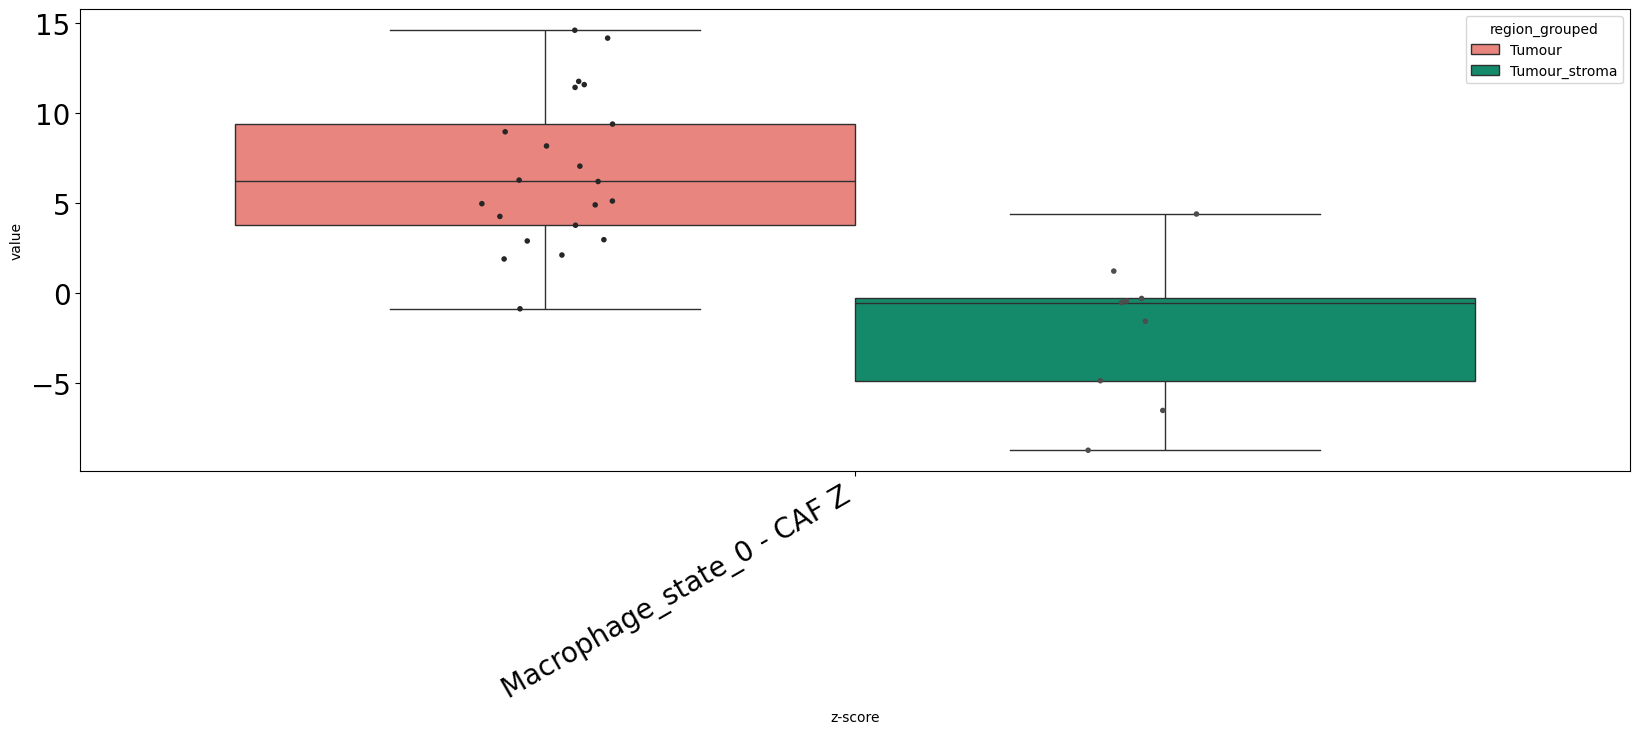

In [ ]:
fig, ax = mosna.plot_distrib_groups(
    data_comparaison, 
    group_var=col,
    groups=[group_ref, group_tgt], 
    pval_data=pvals,
    pval_col='pval_corr',
    var_name=stat_observed
)
if col == 'region_grouped' or col == "Stage":
    extra = f'{group_ref}_{group_tgt}'
else :
    extra= ''
plt.savefig(save_dir / f'{stat_observed}_comparaison_{col}_{extra}', bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

In [437]:
pvals

,pval,pval_corr
Macrophage_state_0 - CAF Z,0.000172,0.032768
Tumour cells (KRT17- S100A2-) - Macrophage_state_0 Z,0.000978,0.092916
Tumour cells (KRT17- S100A2-) - CAF Z,0.002806,0.133266
Tumour cells (KRT17- S100A2-) - Macrophage_state_3 Z,0.002806,0.133266
Monocyte - Macrophage_state_0 Z,0.005769,0.218121
...,...,...
Tumour cells (KRT17- S100A2+) - DC Z,1.000000,1.000000
Tumour cells (KRT17+ S100A2+) - B Cell Z,1.000000,1.000000
Macrophage_state_3 - Macrophage_state_2 Z,1.000000,1.000000
Mesenchymal tumour - Mesenchymal tumour Z,1.000000,1.000000


## Niches

### Paramètres

In [702]:

cols = [
    "location",
    "Diabetes",
    "Pancreatitis",
    "Stage",
    "Treatment before tissue collection",
    "Grade",
    ]

from itertools import combinations
groups = {
    "Stage" : ["IIA", "IIB", "III"],
    "Grade" : ["2","3"],
    "location" : ["Tumour", "Tumour_stroma", "Dysplasia", "Adjacent_normal"],
    "Diabetes" : ["Yes", "No"],
    "Pancreatitis" : ["Yes", "No"],
    "Treatment before tissue collection" : ["Yes", "No"],
}


col = 'location'
group_ref = "Tumour"
group_tgt = "Dysplasia"

without_adjacent_normal = False

# récup stats data sans le générer
dir = Path("./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/assortativity/500_shuffles")

mapping_col = {
    'Not confirmed' : 'Yes',
    'Yes, chemotherapy' : 'Yes',
    'Yes, chemoradiotherapy' : 'Yes'
    
}
reducer_dir_name = "reducer-umap_dim-2_nneigh-20_metric-manhattan_min_dist-0.0"
cluster_params = {
    'reducer_type' : 'umap',
   'clusterer_type':'leiden',
   'n_clusters':7,
   'force_recompute' : False,
   'resolution' : 0.05,
   'n_neighbors' : 20,
   'k_cluster' : 15
   #résolution que pour leiden
   
}


#save dir pour les plots et pvals 
if without_adjacent_normal:
    save_dir = Path("OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/analyses_complementaires_niches_20_merged/comparaisons/without_adjacent_normal")

if without_adjacent_normal == False:
    save_dir = Path("OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/analyses_complementaires_niches_20_merged/comparaisons")
save_dir.mkdir(parents= True, exist_ok=True)

In [703]:
def get_reducer_dir_name(cluster_params, reducer_dir_name):
    #fonction pour récupérer le nom du dossier cluster
    #cluster_params = dico
    #reducer dir name = str
    if cluster_params["clusterer_type"] == 'leiden':
        k_cluster = str(cluster_params["k_cluster"])
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}_n_neighbors-{k_cluster}'
    elif cluster_params["clusterer_type"] == 'spectral' or cluster_params["clusterer_type"] == 'ecg':
        k_cluster = str(cluster_params["k_cluster"])
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}_n_neighbors-{k_cluster}'
    else : 
        clusterer_dir_name = f'clusterer-{cluster_params["clusterer_type"]}'
    return clusterer_dir_name

In [704]:


clusterer_dir_name = get_reducer_dir_name(cluster_params, reducer_dir_name)

chemin = f'./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/niches/results_niche/{reducer_dir_name}/{clusterer_dir_name}/OUTPUT_merged/nodes_cluster_leiden_labeled.parquet'


nodes_cluster_labeled_file_path = Path(chemin)

info_metadata_path = Path('./images_metadatainfo.csv')




### Récupération des données

In [705]:
#je recupère le data frame avec tous les nodes et leur cluster

nodes_cluster_labeled = pd.read_parquet(nodes_cluster_labeled_file_path)

In [706]:
# récup stats data sans le générer

stats_data = pd.read_parquet(dir / "group_stats_data_assortativity.parquet")

info_metadata_path = Path('./images_metadatainfo.csv')
metadata = pd.read_csv(info_metadata_path)

#Je recupère patient et sample en pour chaque ligne de metainfo data et je mets ça dans colonne image sachant que de la forme 4 derniers chiffre = 2 premiers patient, deux derniere sample
metadata = metadata.copy()

metadata["patient"] = metadata["image"].str[6:8]
metadata["sample"] = metadata["image"].str[8:10]

metadata["id"] = "patient-" + metadata["patient"] + "_sample-" + metadata["sample"]

metadata = metadata.set_index('id')

In [707]:
#je récupère nodes_cluster_labeled_and_metadata = nodes_cluster_labeled (données nodes avec cluster) mais avec localisation précisée (region_grouped)

nodes_cluster_labeled_and_metadata = nodes_cluster_labeled.copy()
#je crée colone id  car source file colonne existe dans metainfo pour designer
#autre chose et ça va poser problème quand je vais réunir les deux dataframe. Et aussi, dans source file ça commence par
#nodes_ donc je supprime ça. 

import re

# -------------------------------
# Côté nodes
# -------------------------------

nodes_cluster_labeled_and_metadata["id"] = (
    nodes_cluster_labeled_and_metadata["source_file"]
    .str.replace("nodes_", "", regex=False)
    .str.replace(".parquet", "", regex=False)
    .str.strip()
)

nodes_cluster_labeled_and_metadata["id"] = (
    nodes_cluster_labeled_and_metadata["id"]
    .map(
        lambda x: re.sub(r'(\D)0+(\d+)', r'\1\2', x)
    )
)


# -------------------------------
# Côté metadata
# -------------------------------

metadata.index = (
    metadata.index
    .astype(str)
    .map(
        lambda x: re.sub(r'(\D)0+(\d+)', r'\1\2', x)
    )
)

metadata.index.name = "id"


nodes_cluster_labeled_and_metadata = nodes_cluster_labeled_and_metadata.merge(
    metadata,
    left_on="id",
    right_index=True,
    how="left"
)
#nodes_cluster_labeled_and_metadata = nodes_cluster_labeled_and_metadata.set_index('id')
#nodes_cluster_labeled_and_metadata = nodes_cluster_labeled_and_metadata.join(metadata, how='inner')
#on standarise les noms de pathologie pour éviter les problèmes de mapping, parfois poorly est écrit avec un p minuscule et parfois avec un P majuscule.
nodes_cluster_labeled_and_metadata['Pathology'] = nodes_cluster_labeled_and_metadata['Pathology'].replace({
    'poorly differentiated ductal carcinoma':'Poorly differentiated ductal carcinoma' 
   
    })
mapping = {
    'tumour': 'Tumour',
    'tumour centre': 'Tumour',
    'tumour_invasive area': 'Tumour',
    'tumour + islets': 'Tumour',
    'tumour incl. stroma and islets': 'Tumour',
    'tumor intraductal spread': 'Tumour',

    'tumour stroma': 'Tumour_stroma',
    'adjacent stroma': 'Tumour_stroma',

    'dysplasia': 'Dysplasia',
    'dysplasia + islets': 'Dysplasia',

    'adjacent normal': 'Adjacent_normal'
}

mapping2 = {
    'tumour': 'Tumour',
    'tumour centre': 'Tumour_centre',
    'tumour_invasive area': 'Tumour_invasive_area',
    'tumour + islets': 'Tumour',
    'tumour incl. stroma and islets': 'Tumour',
    'tumor intraductal spread': 'Tumour',

    'tumour stroma': 'Stroma',
    'adjacent stroma': 'Stroma',

    'dysplasia': 'Dysplasia',
    'dysplasia + islets': 'Dysplasia',

    'adjacent normal': 'Adjacent_normal'
}
nodes_cluster_labeled_and_metadata['location'] = nodes_cluster_labeled_and_metadata['Notes'].map(mapping)
#nodes_cluster_labeled_and_metadata = nodes_cluster_labeled_and_metadata.reset_index()



In [708]:
#définition des fonctions utilisées
import pandas as pd

def loc_count_niche(nodes_by_loc):
    #créer comme une matrice avec en index localisation et en colonne les clusters/niches. 
    # les valeurs de la matrice = nombre de cell dans chaque niche selon loc
    #nodes_by_loc = dict avec différents dataframes pour chaque location et contenant chacuns les nodes
    keys = list(nodes_by_loc.keys())
    df_total = []

    for key in keys:
        df = nodes_by_loc[key]
        
        df_count = df["Niche"].value_counts().to_dict()
        df_count["loc"] = key
        
        df_total.append(df_count)

    return  pd.DataFrame(df_total).set_index("loc").fillna(0)

def sample_count_niche(nodes_by_sample):
     #créer comme une matrice avec en index patient-sample et en colonne les clusters/niches. 
    # les valeurs de la matrice = nombre de cell dans chaque niche selon loc
    #nodes_by_sample = dict avec différents dataframes pour chaque sample et contenant chacuns les nodes
    keys = list(nodes_by_sample.keys())
    df_total = []

    for key in keys:
        df = nodes_by_sample[key]
        
        df_count = df["Niche"].value_counts().to_dict()
        df_count["id"] = key
        
        df_total.append(df_count)

    return  pd.DataFrame(df_total).set_index("id").fillna(0)




In [709]:
nodes_cluster_labeled_and_metadata

,Object,Phenotype,area,centroid-0,centroid-1,axis_major_length,axis_minor_length,eccentricity,Macro_label,double_status,...,Pathology,Stage,Grade,Location in pancrea,Treatment before tissue collection,Diabetes,Pancreatitis,patient,sample,location
0,1,CAF,15,0.800000,307.600000,6.342285,2.973565,0.883279,NaN,None,...,Poorly differentiated ductal carcinoma,IIB,3,Neck,No,Yes,No,04,01,Tumour
1,2,Unknown,7,0.428571,589.714286,4.155375,1.905471,0.888666,NaN,None,...,Poorly differentiated ductal carcinoma,IIB,3,Neck,No,Yes,No,04,01,Tumour
2,3,B Cell,8,0.500000,602.500000,4.472136,2.000000,0.894427,NaN,None,...,Poorly differentiated ductal carcinoma,IIB,3,Neck,No,Yes,No,04,01,Tumour
3,4,CAF,18,0.888889,1159.166667,7.086920,3.235263,0.889717,NaN,None,...,Poorly differentiated ductal carcinoma,IIB,3,Neck,No,Yes,No,04,01,Tumour
4,5,DC,6,0.500000,1324.000000,3.265986,2.000000,0.790569,NaN,None,...,Poorly differentiated ductal carcinoma,IIB,3,Neck,No,Yes,No,04,01,Tumour
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
543082,11150,CAF,6,1087.500000,1741.000000,3.265986,2.000000,0.790569,NaN,None,...,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,03,Dysplasia
543083,11151,Epithelial Cell,14,1087.071429,1908.142857,5.449354,3.145851,0.816540,NaN,None,...,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,03,Dysplasia
543084,11152,Unknown,9,1087.555556,50.777778,5.274258,1.946056,0.929440,NaN,None,...,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,03,Dysplasia
543085,11153,CAF,4,1087.500000,219.500000,2.000000,2.000000,0.000000,NaN,None,...,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,03,Dysplasia


In [710]:
def prepare_niche_dataframe(
    nodes_cluster_labeled_and_metadata,
    col,
    mapping_col,
    without_adjacent_normal=False,
):
    # Sélection des données
    if without_adjacent_normal:
        data = nodes_cluster_labeled_and_metadata.loc[
            nodes_cluster_labeled_and_metadata["location"] != "Adjacent_normal",
            ["Niche", "id", col],
        ].copy()
    else:
        data = nodes_cluster_labeled_and_metadata[
            ["Niche", "id", col]
        ].copy()

    # Création du dictionnaire : une clé = un patient/échantillon
    nodes_by_sample = dict(tuple(data.groupby("id")))

    # Comptage des niches par patient
    df = sample_count_niche(nodes_by_sample)

    # Ajout de la variable d'intérêt
    df_patient_grade = data.groupby("id", as_index=False)[col].first()
    df[col] = df_patient_grade.set_index("id")[col].reindex(df.index)

    # Sauvegarde des labels
    df["image"] = df.index.astype(str)
    image = df["image"]

    df = df.drop(columns="image")   # <-- il manque cette ligne

    df = df.reset_index()
    df = df.drop(columns="id")

    data_group = df[[col]].copy()
    df = df.drop(columns=col)

    # Normalisation
    df = df.div(df.sum(axis=1), axis=0)

    df[col] = data_group[col].replace(mapping_col)

    return df, image

There are 0 significant variables in `pval_corr`


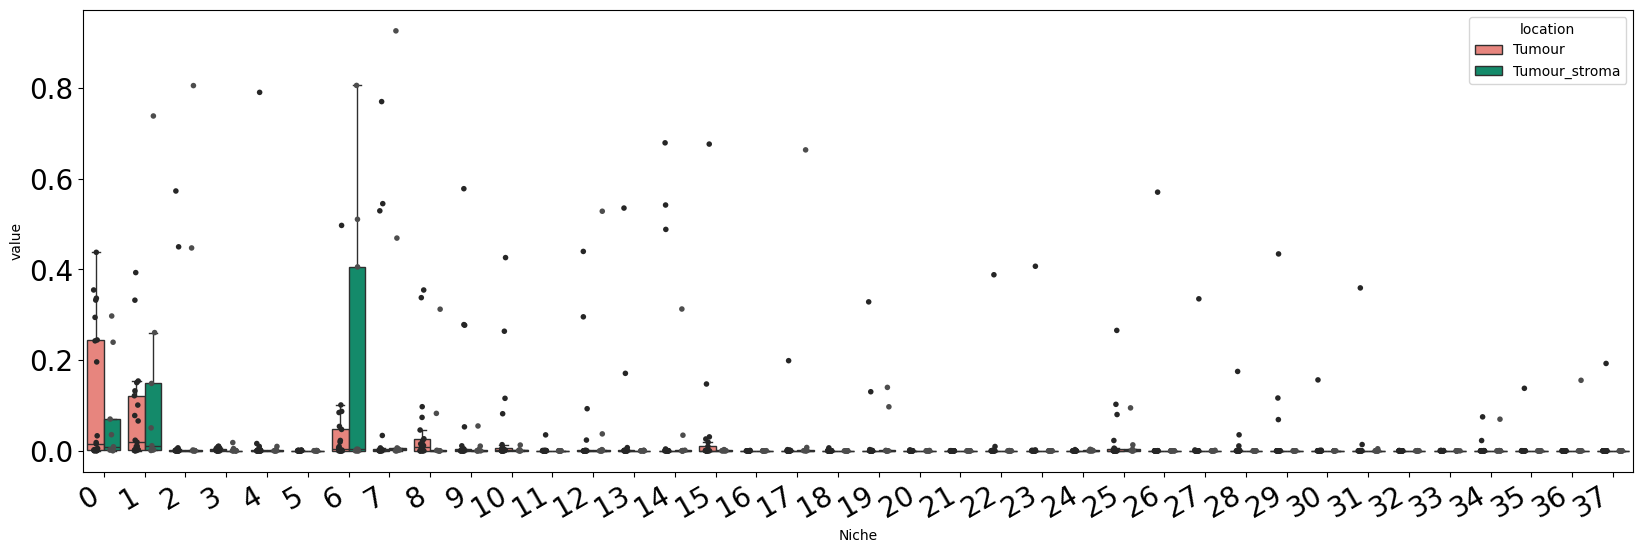

There are 0 significant variables in `pval_corr`


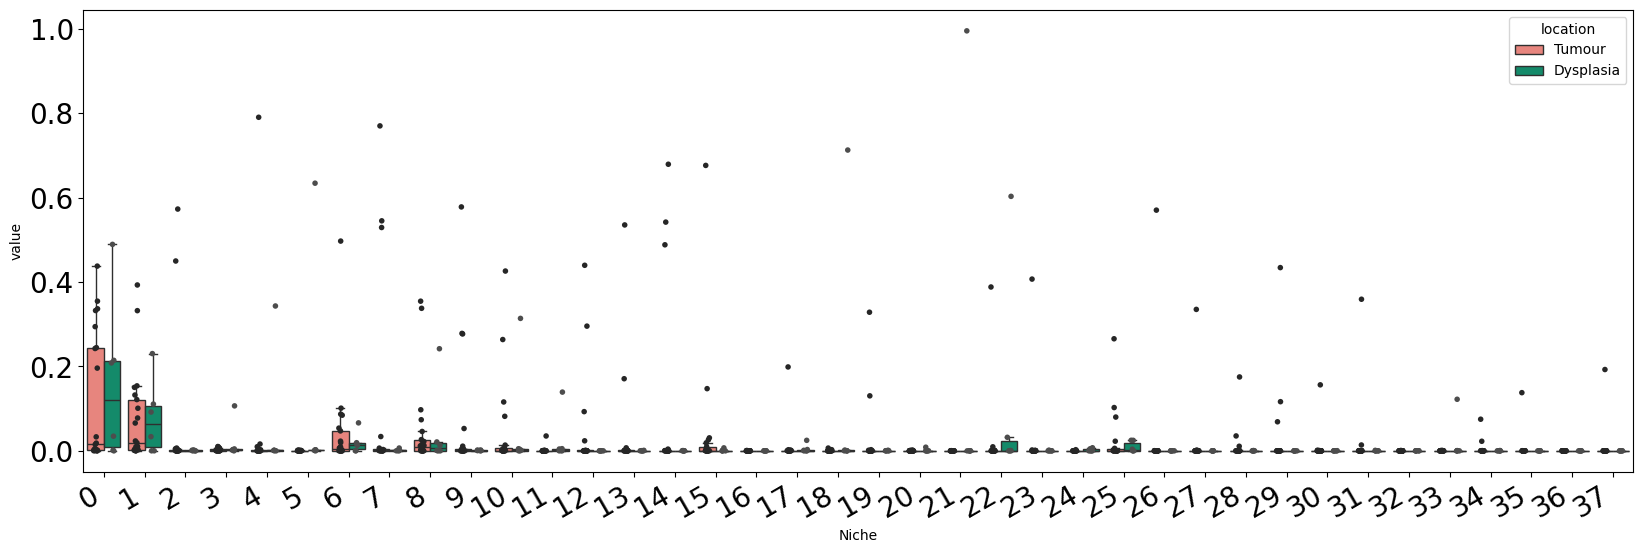

There are 0 significant variables in `pval_corr`


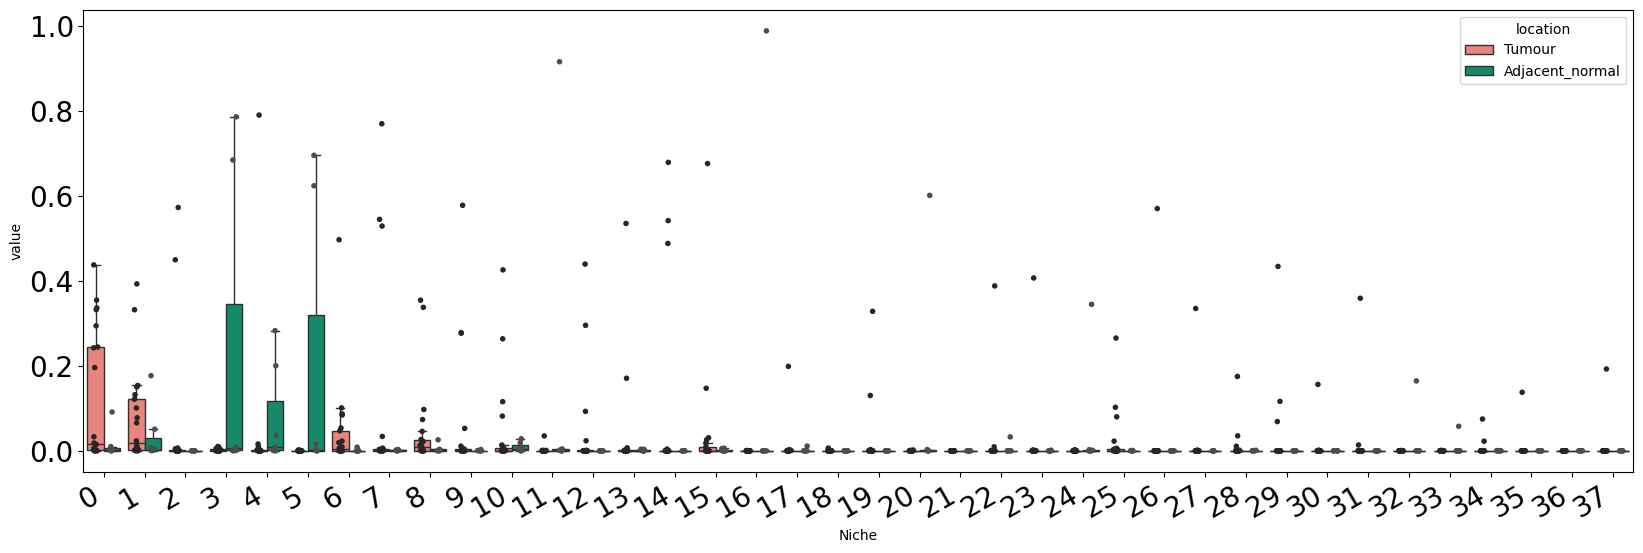

There are 0 significant variables in `pval_corr`


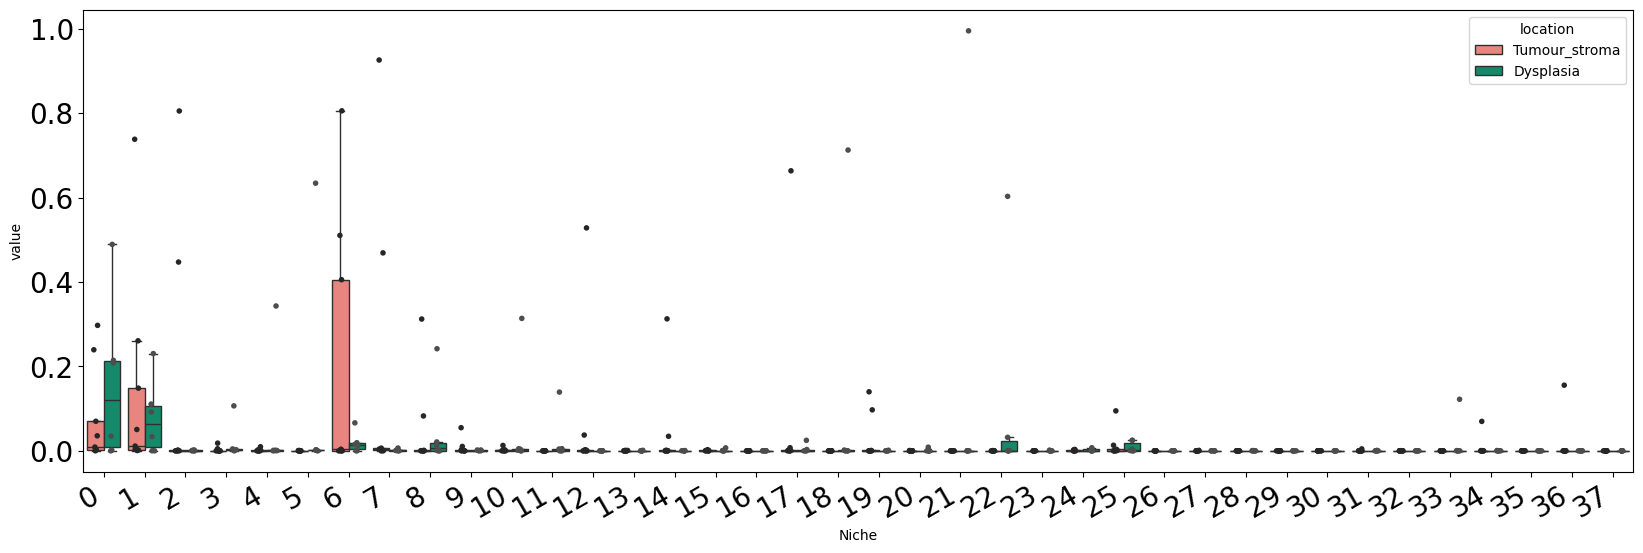

There are 0 significant variables in `pval_corr`


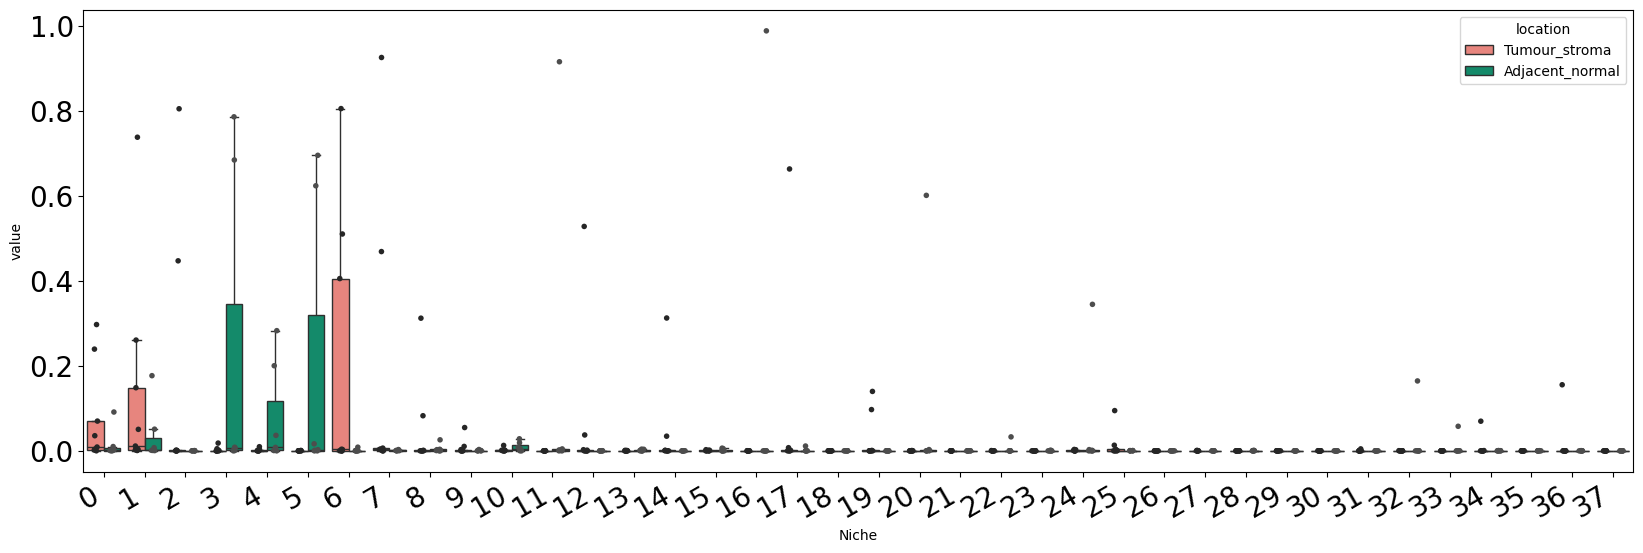

There are 0 significant variables in `pval_corr`


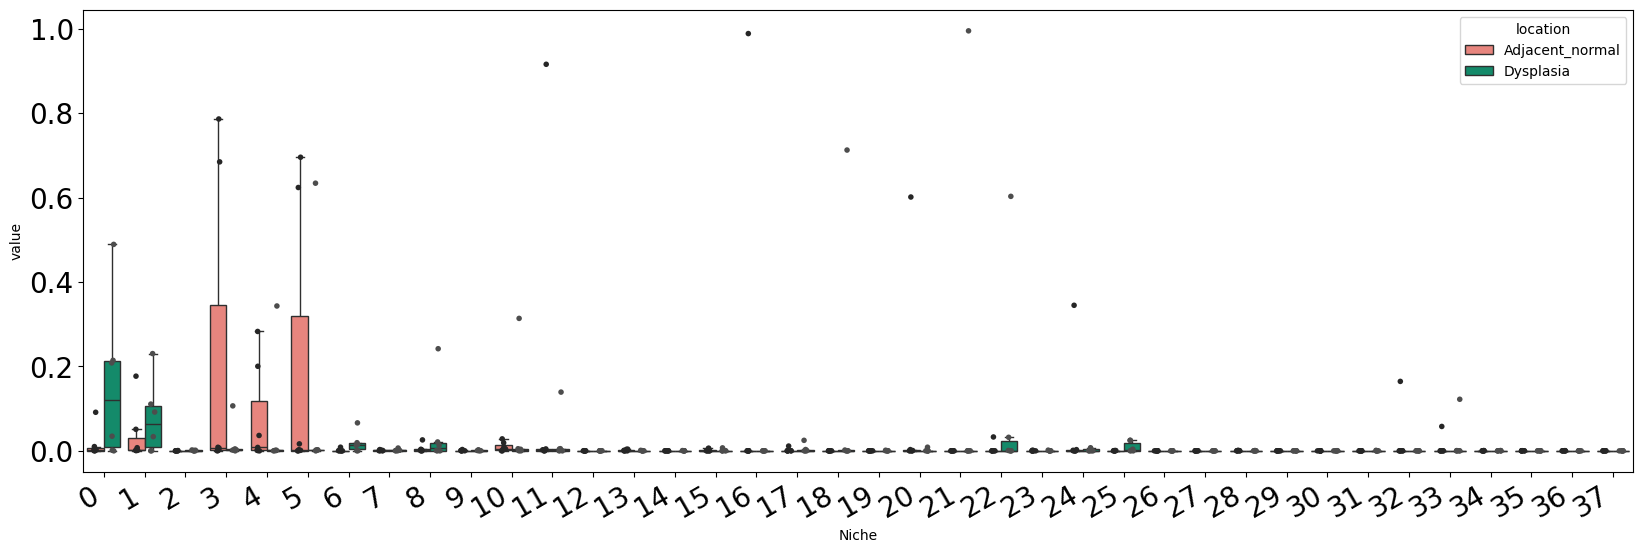

There are 0 significant variables in `pval_corr`


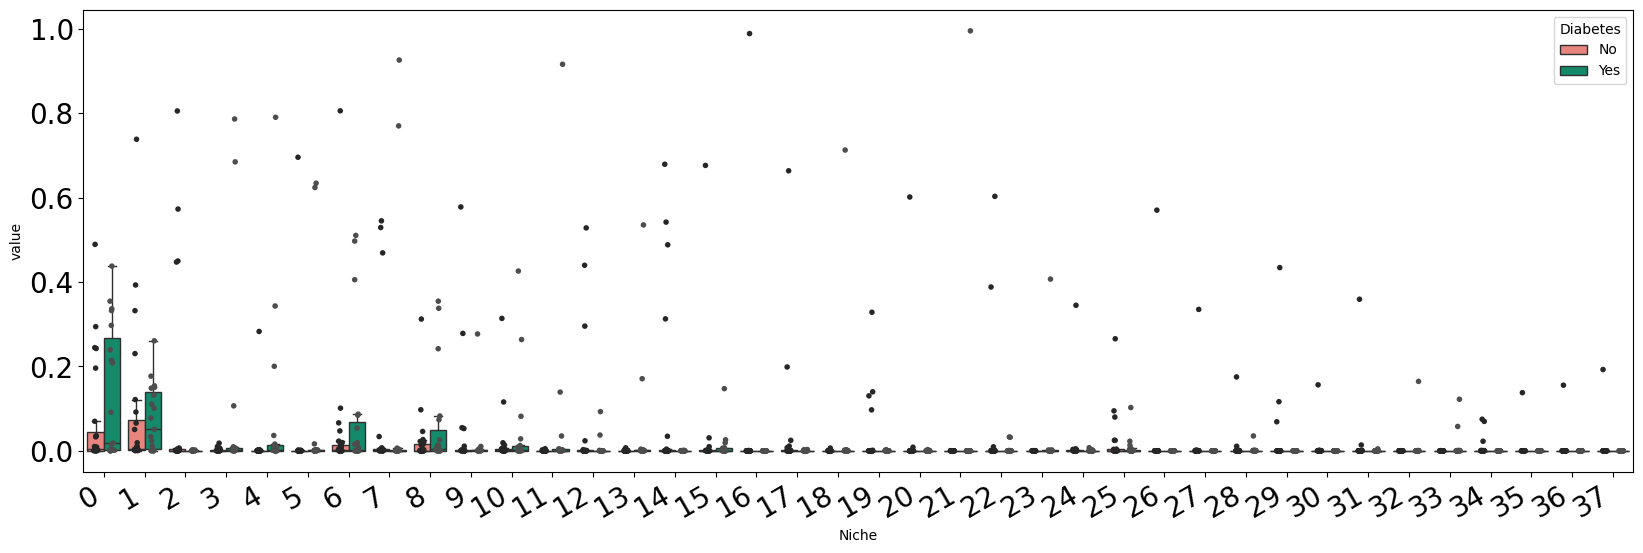

There are 1 significant variables in `pval_corr`


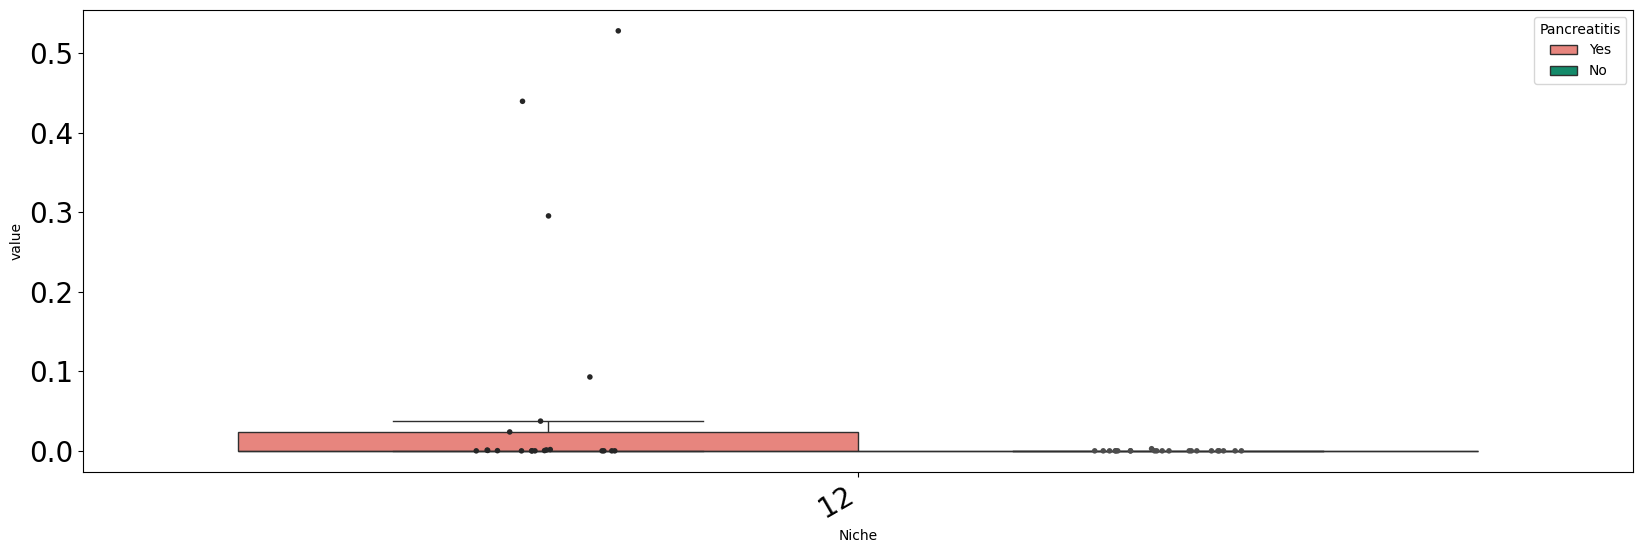

There are 0 significant variables in `pval_corr`


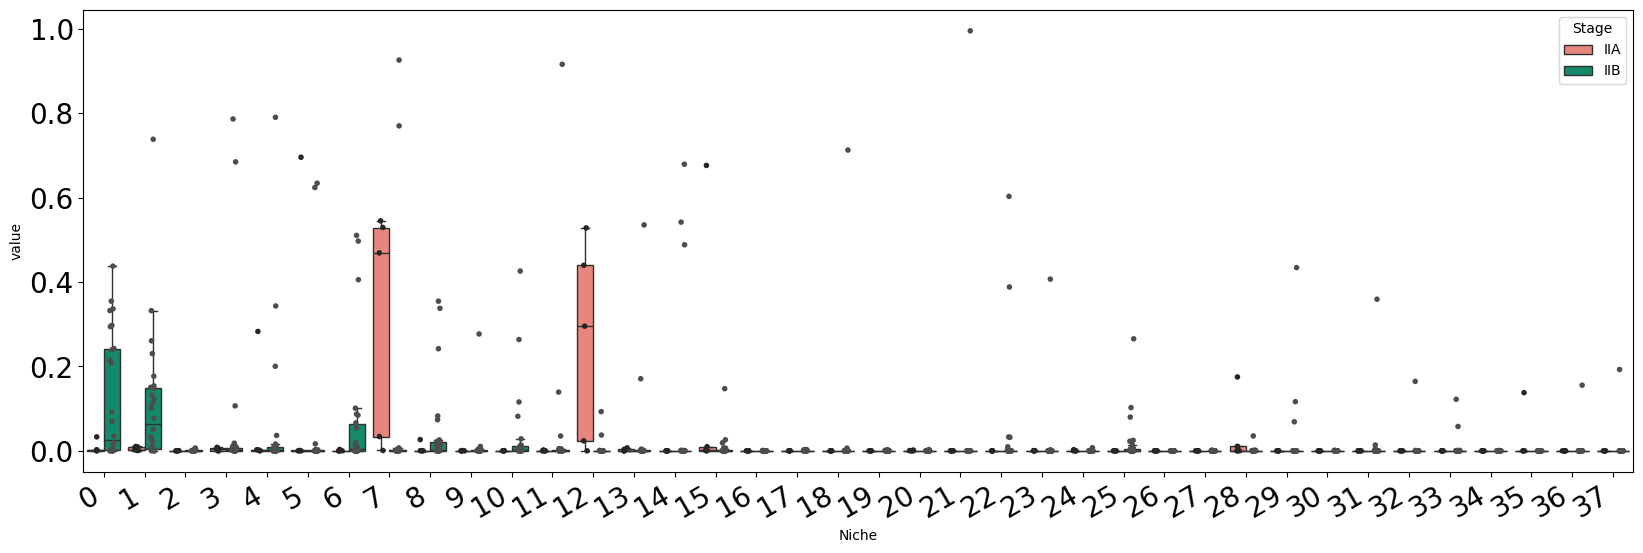

There are 0 significant variables in `pval_corr`


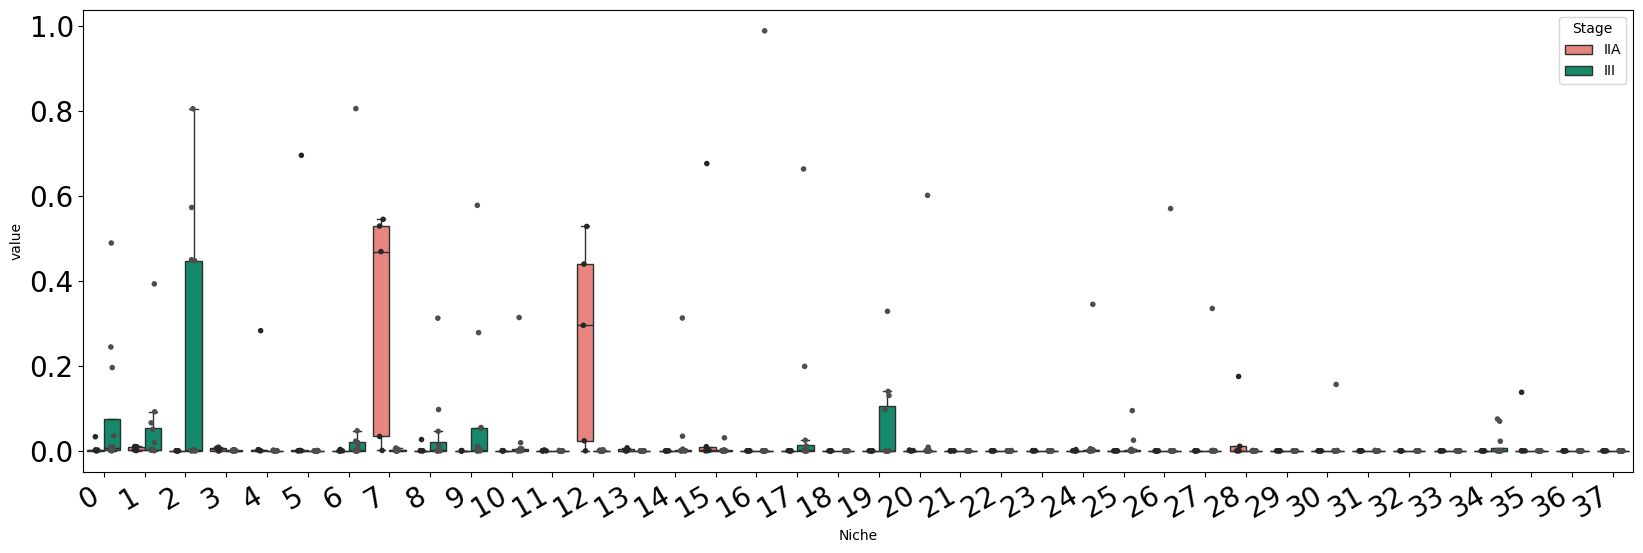

There are 0 significant variables in `pval_corr`


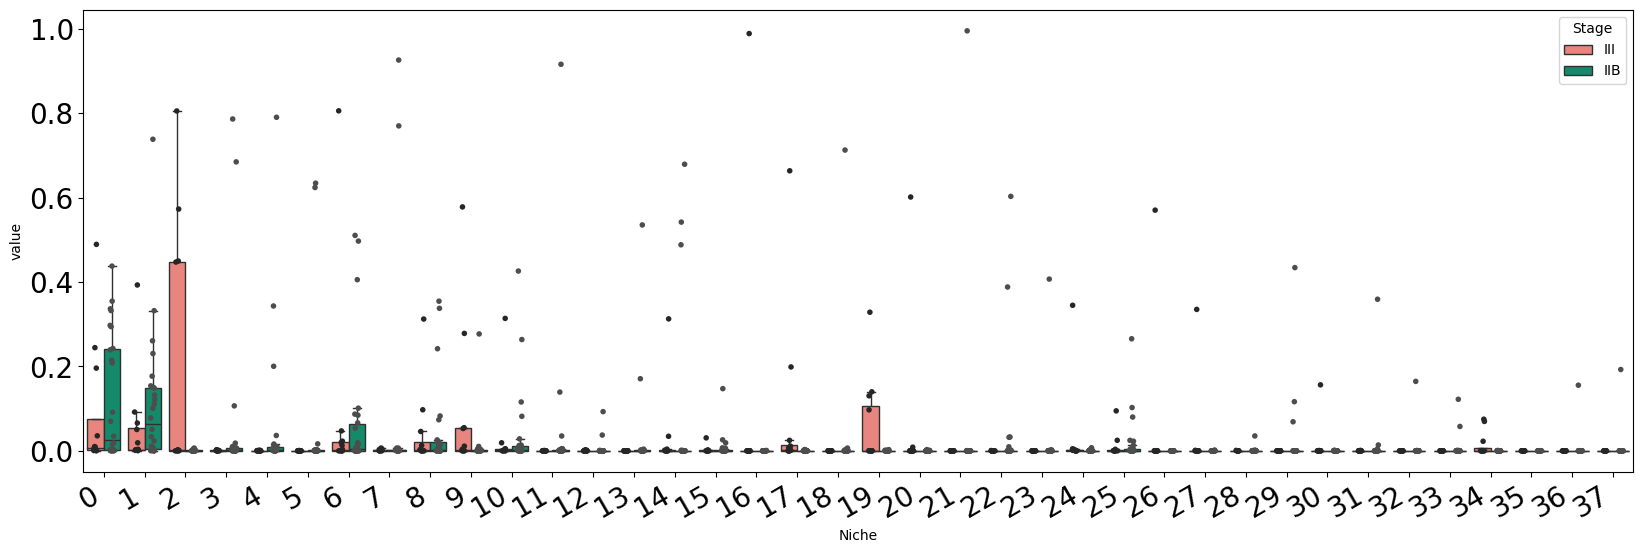

There are 7 significant variables in `pval_corr`


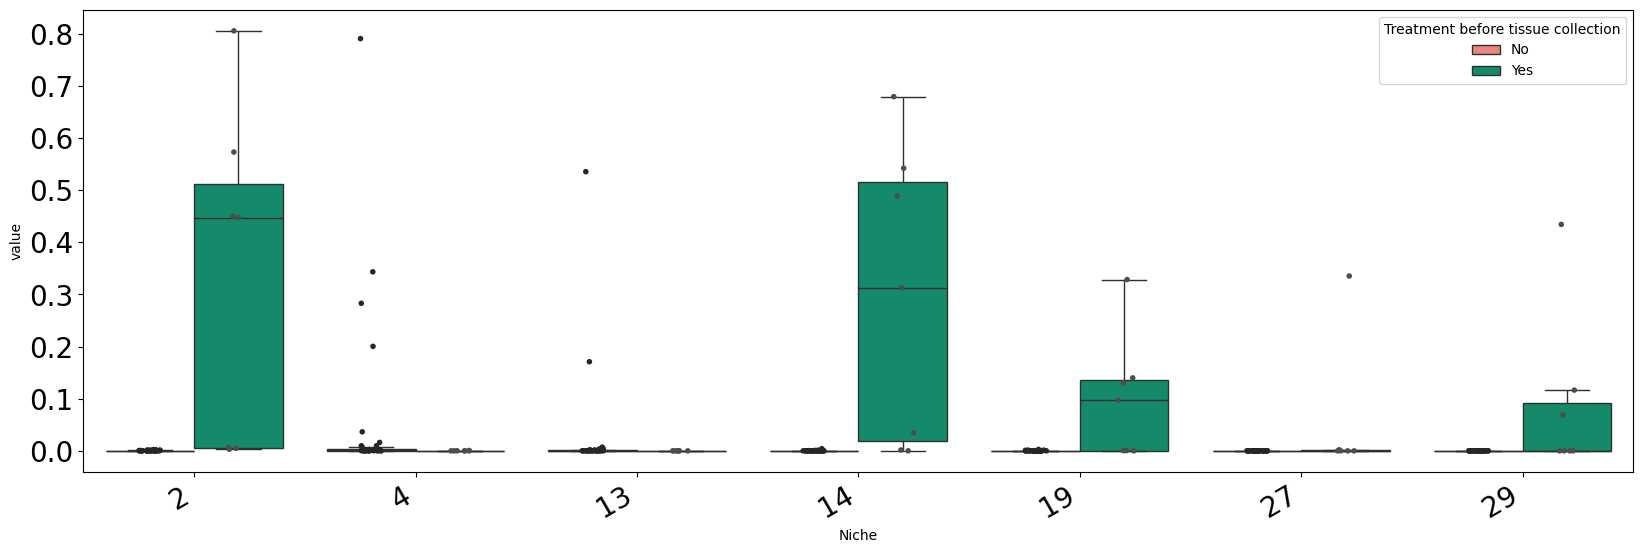

There are 1 significant variables in `pval_corr`


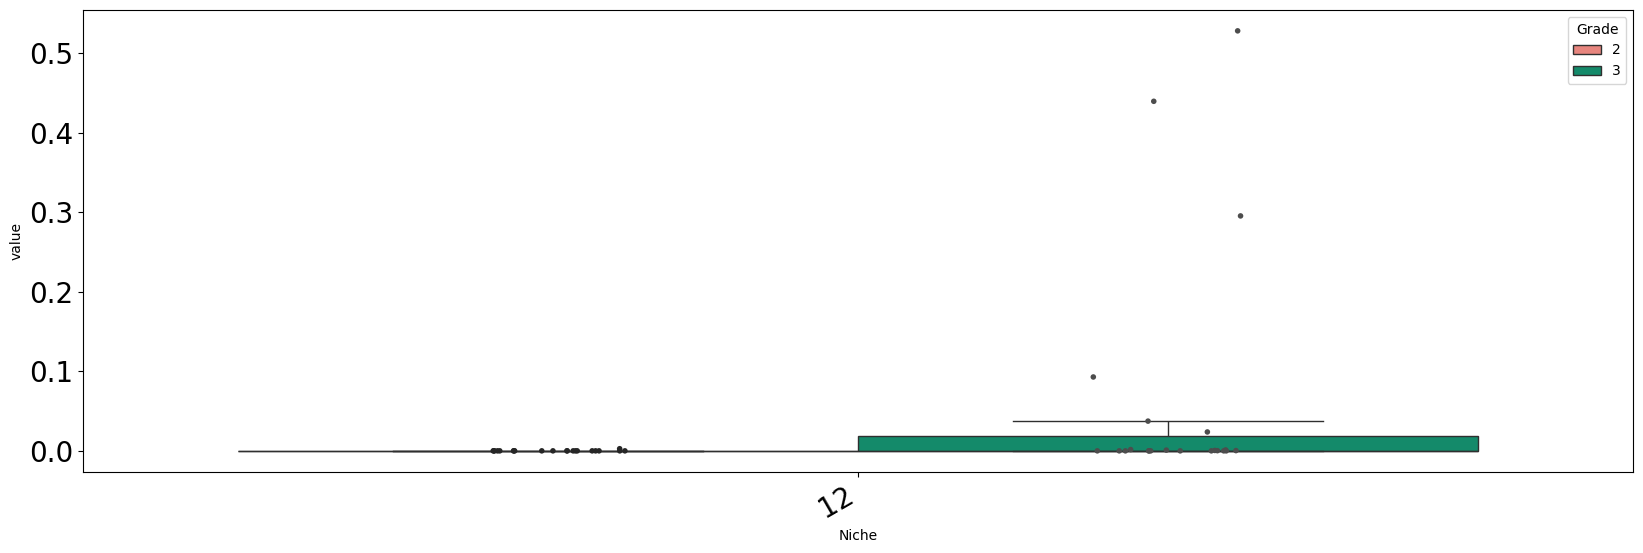

In [711]:

for col in cols :
    for group_ref, group_tgt in combinations(groups[col], 2):
        if col == "Grade":
            group_ref = int(group_ref)
            group_tgt = int(group_tgt)
        df, image = prepare_niche_dataframe(
        nodes_cluster_labeled_and_metadata,
        col=col,
        mapping_col=mapping_col,
        without_adjacent_normal=without_adjacent_normal,
        )

        
        # tests = Kolmogorov-Smirnov et Mann-Whitney
        pvals = mosna.find_DE_markers(
                df, 
                group_ref= group_ref, 
                group_tgt= group_tgt, 
                group_var=col,
                test='Mann-Whitney',
                )

        
        if col == 'location' or col == "Stage":
            extra = f'{group_ref}_{group_tgt}'
        else :
            extra= ''

        pvals.to_parquet(save_dir / f'model_{stat_observed}_{col}_{extra}-pvals-test-MW')
        select_pvals = pvals['pval_corr'] <= 0.05
        n_pvals_corr = select_pvals.sum()

        fig, ax = mosna.plot_distrib_groups(
        df, 
        group_var=col,
        groups=[group_ref, group_tgt], 
        pval_data=pvals,
        pval_col='pval_corr',
        var_name='Niche'
    )
        if col == 'location' or col == "Stage":
            extra = f'{group_ref}_{group_tgt}'
        else :
            extra= ''
        plt.savefig(save_dir / f'niche_comparaison_{col}_{extra}', bbox_inches='tight', facecolor='white', dpi=150)
        plt.show()



In [712]:
print(df.dtypes)

7        float64
12       float64
1        float64
0        float64
15       float64
20       float64
8        float64
4        float64
23       float64
17       float64
9        float64
19       float64
35       float64
28       float64
3        float64
5        float64
10       float64
13       float64
2        float64
11       float64
18       float64
6        float64
25       float64
24       float64
32       float64
26       float64
14       float64
31       float64
30       float64
16       float64
21       float64
27       float64
34       float64
33       float64
22       float64
37       float64
29       float64
36       float64
Grade      int64
dtype: object


# stop

In [466]:
data = nodes_cluster_labeled_and_metadata[['Niche','id',col]]

if without_adjacent_normal:
    df_copy = nodes_cluster_labeled_and_metadata.copy()

    df_t = df_copy[
        df_copy["location"] != "Adjacent_normal"
    ]

    data = data = df_t[['Niche','id',col]]
#réation dictionnaire avec chaque key est une image et contenant nodes, donc une key = patient-sample
nodes_by_sample = dict(tuple(data.groupby("id")))

#création Matrice id(patient-sample) / niche avec nombre de cell dans niche par id
df= sample_count_niche(nodes_by_sample)
df_patient_grade = data.groupby("id", as_index=False)[col].first()



df[col] = df_patient_grade.set_index("id")[col].reindex(df.index)

df['image']= df.index.astype(str) 
image = df['image']
df = df.drop(columns='image')
df = df.reset_index()
df = df.drop(columns='id')
data_group = df[[col]].copy()

df = df.drop(columns = col)

#normalisation par ligne/patient

df = df.div(df.sum(axis=1), axis=0)



df[col] = data_group[col]


df[col] = df[col].replace(mapping_col)




In [ ]:
nodes_cluster_labeled_and_metadata.columns

Index(['Object', 'Phenotype', 'area', 'centroid-0', 'centroid-1',
       'axis_major_length', 'axis_minor_length', 'eccentricity', 'Macro_label',
       'double_status', 'cell_id', '89Y-Collagen-I', '142Nd-CA9',
       '143Nd-Vimentin', '144Nd-CD14', '145Nd-CD31', '146Nd-CD11b',
       '147Sm-CD163', '148Nd-Pan-Keratin', '149Sm-CD15', '150Nd-CD274',
       '151Eu-LYVE1', '153Eu-CD16', '154Sm-CD11c', '155Gd-FoxP3', '156Gd-CD4',
       '158Gd-E-Cadherin', '159Tb-CD68', '160Gd-FAP', '161Dy-CD20',
       '162Dy-CD8a', '163Dy-CD206', '164Dy-KRT17', '166Er-CD74',
       '167Er-Granzyme_B', '168Er-Ki-67', '169Tm-FOLR2', '170Er-CD3',
       '171Yb-MS4A4A', '172Yb-S100A2', '173Yb-CD45RO', '174Yb-Keratin_8_18',
       '176Yb-Histone_H3', '191Ir-DNA1', '193Ir-DNA2', '195Pt-ICSK1',
       '196Pt-ICSK2', '198Pt-ICSK3', '209Bi-aSMA', 'source_file_x', 'Niche',
       'id', 'image', 'width_px', 'height_px', 'num_channels', 'source_file_y',
       'recovery_file', 'recovered', 'original image  ID', 'No

### Comparaison et plot

In [ ]:


# tests = Kolmogorov-Smirnov et Mann-Whitney
pvals = mosna.find_DE_markers(
        df, 
        group_ref= group_ref, 
        group_tgt= group_tgt, 
        group_var=col,
        test='Mann-Whitney',
        )


pvals.to_parquet(save_dir / f'model_{col}-pvals_niche-test-KS')
select_pvals = pvals['pval_corr'] <= 0.05
n_pvals_corr = select_pvals.sum()


There are 0 significant variables in `pval_corr`


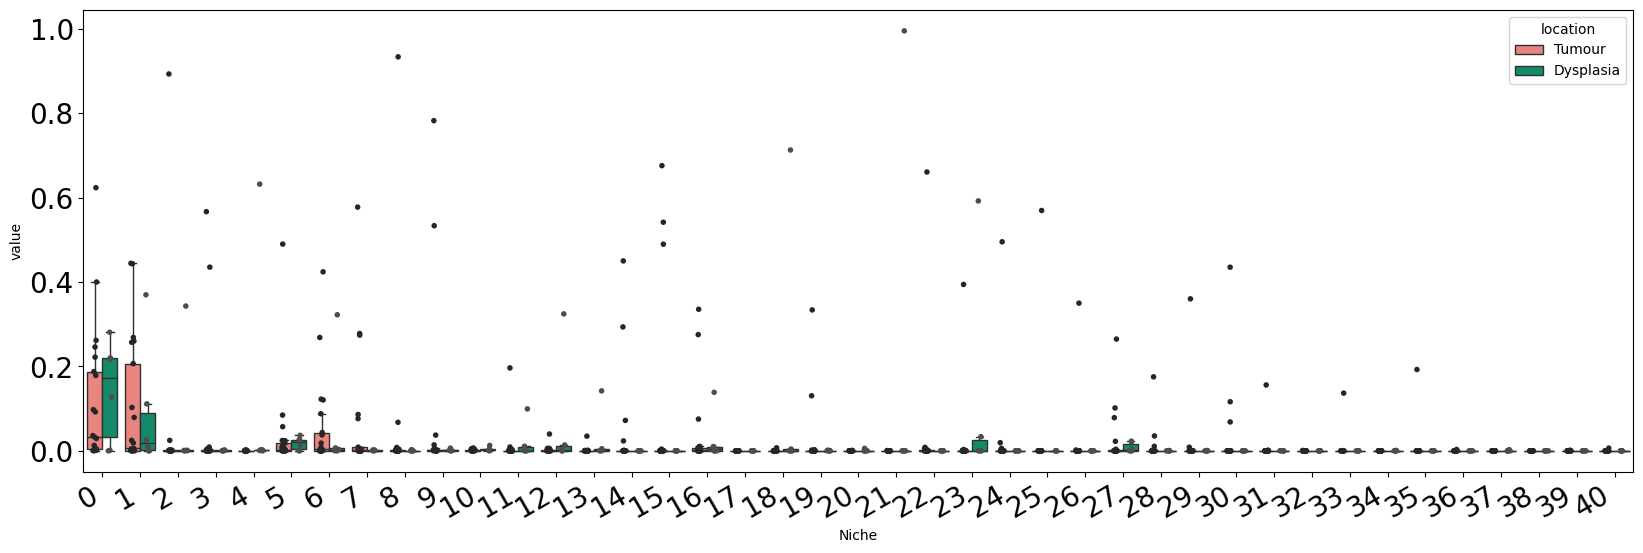

In [ ]:
fig, ax = mosna.plot_distrib_groups(
    df, 
    group_var=col,
    groups=[group_ref, group_tgt], 
    pval_data=pvals,
    pval_col='pval_corr',
    var_name='Niche'
)

#ax.set_ylim(0, 0.020)
plt.savefig(save_dir / f'niche_comparaison_{col}', bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

In [ ]:
col = 'Grade'
save_dir = Path('./OUTPUT/niches/comparaisons_15')

test = pd.read_parquet(save_dir / f'model_{col}-pvals_niche-test-KS')
select_pvals_test = test['pval_corr'] <= 0.05
n_pvals_corr_test = select_pvals_test.sum()

In [ ]:
test
n_pvals_corr_test
select_pvals_test

11     True
15     True
22    False
27    False
37    False
      ...  
38    False
50    False
18    False
53    False
34    False
Name: pval_corr, Length: 73, dtype: bool

In [ ]:
df_count = sample_count_niche(nodes_by_sample)

test['Niche'] = select_pvals_test

In [ ]:
type(select_pvals_test)
test['Niche_name'] = test.index


In [ ]:
true_niche = pd.DataFrame()
true_niche['Niche'] = test.loc[test['Niche'], 'Niche_name'].copy()




In [ ]:
true_niche

,Niche
11,11
15,15


In [ ]:
cols = true_niche['Niche'].tolist()
df_select_patient = df_count.loc[:, cols]
#df_select_patient = df_select_patient.drop(columns=[1,0,3])
df_select_patient = df_select_patient.loc[(df_select_patient != 0).any(axis=1)]

In [ ]:
df_select_patient 

,11,15
id,,
patient-01_sample-01,0.0,57.0
patient-01_sample-02,0.0,6445.0
patient-01_sample-03,0.0,7137.0
patient-01_sample-04,0.0,195.0
patient-02_sample-01,0.0,3.0
patient-02_sample-02,0.0,2.0
patient-02_sample-03,0.0,100.0
patient-02_sample-04,0.0,2.0
patient-03_sample-01,0.0,4.0


## markers comparaison

In [1]:
import pandas as pd
import numpy as np

import glob
import os

from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
#from phenograph.cluster import cluster
import glob
from pathlib import Path
from tqdm import tqdm
import json
import numpy as np
import os, random
from scipy.stats import zscore

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


In [ ]:


folder_directory = "./arcsinh/Steinbock/"
morphology_path = Path('./arcsinh/Steinbock/regionprops')

folder_saving = Path(folder_directory) / "Figures"
folder_saving.mkdir(exist_ok=True)

WHOLE_SAMPLE = True
LOAD_DATA = False


RUN_PHENOGRAPH = not LOAD_DATA

folder_directory = Path(folder_directory)
marker_directory = folder_directory / "intensities"
info_path = Path(folder_directory) / "informations.json"
files = sorted(list(marker_directory.glob("*")))

with open(info_path) as f:
    data = json.load(f)

functional_markers = data["functional_markers"]
identity_markers = data["identity_markers"]
segmentation_markers = data["segmentation_markers"]

no_markers_cols = ["Object"]
all_markers = data["markers"]

assert set(identity_markers + functional_markers + segmentation_markers) == set(all_markers)

metainfo = pd.read_csv(folder_directory / "images_metadatainfo.csv")



In [3]:
functional_markers = ['89Y-Collagen-I',
 '142Nd-CA9',
 '143Nd-Vimentin',
 #'150Nd-CD274',
 #'151Eu-LYVE1',
 '167Er-Granzyme_B',
 '168Er-Ki-67']

In [4]:
folder = "data/nodes_arcsinh_states_labeled/corrected_double_status_tumour_and_macrostates_labeled/leiden_states"

files = glob.glob(os.path.join(folder, "nodes_*.parquet"))

state_col = "Phenotype"
cellid_col = "cell_id"

df = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

data = df.loc[
    df["Phenotype"].isin([
        "Macrophage_state_0",
        "Macrophage_state_1",
        "Macrophage_state_2",
        "Macrophage_state_3"
    ])
]
print("Phentoypes conservés :\n\n", data["Phenotype"].unique())

drop_cols = [
    "Object",
    "area",
    "centroid-0",
    "centroid-1",
    "axis_major_length",
    "axis_minor_length",
    "eccentricity",
    "Macro_label",
    "double_status"
]
data = data.drop(columns=drop_cols)

print("\n\nColonnes du dataframe data :\n\n", data.columns)

Phentoypes conservés :

 ['Macrophage_state_0' 'Macrophage_state_1' 'Macrophage_state_3'
 'Macrophage_state_2']


Colonnes du dataframe data :

 Index(['Phenotype', 'cell_id', '89Y-Collagen-I', '142Nd-CA9', '143Nd-Vimentin',
       '144Nd-CD14', '145Nd-CD31', '146Nd-CD11b', '147Sm-CD163',
       '148Nd-Pan-Keratin', '149Sm-CD15', '150Nd-CD274', '151Eu-LYVE1',
       '153Eu-CD16', '154Sm-CD11c', '155Gd-FoxP3', '156Gd-CD4',
       '158Gd-E-Cadherin', '159Tb-CD68', '160Gd-FAP', '161Dy-CD20',
       '162Dy-CD8a', '163Dy-CD206', '164Dy-KRT17', '166Er-CD74',
       '167Er-Granzyme_B', '168Er-Ki-67', '169Tm-FOLR2', '170Er-CD3',
       '171Yb-MS4A4A', '172Yb-S100A2', '173Yb-CD45RO', '174Yb-Keratin_8_18',
       '176Yb-Histone_H3', '191Ir-DNA1', '193Ir-DNA2', '195Pt-ICSK1',
       '196Pt-ICSK2', '198Pt-ICSK3', '209Bi-aSMA'],
      dtype='object')


In [5]:

df = data.copy()
# exemple P4_S1_24

df["patient"] = (
    df["cell_id"]
    .str.extract(r"(P\d+)")
)


df["sample"] = (
    df["cell_id"]
    .str.extract(r"(P\d+_S\d+)")
)


df[["cell_id","patient","sample"]].head(10)
marker_cols = [
    col for col in df.columns 
    if col != state_col and col != cellid_col and col != "sample" and col != "patient"
]
markers_to_remove = list(set(segmentation_markers + functional_markers))

marker_cols = [
    marker
    for marker in marker_cols
    if marker not in markers_to_remove
]

sample_df = (
    df
    .groupby(
        ["sample", state_col]
    )[marker_cols]
    .mean()
    .reset_index()
)

global_mean = sample_df[marker_cols].mean()

enrichment = sample_df.copy()

enrichment[marker_cols] = enrichment[marker_cols] - global_mean

enrichment = enrichment.set_index([ "sample", state_col ])

print("enrichment\n")
enrichment

enrichment



144Nd-CD14  145Nd-CD31  146Nd-CD11b  147Sm-CD163  \
sample Phenotype                                                              
P10_S1 Macrophage_state_0    0.034121   -0.002959    -0.062325     0.000849   
       Macrophage_state_2    0.123566   -0.003379    -0.064217    -0.001046   
       Macrophage_state_3   -0.121067    0.042089     0.160214    -0.001046   
P10_S2 Macrophage_state_0    0.022297   -0.002462    -0.059997     0.000837   
       Macrophage_state_1   -0.201133   -0.003379    -0.064217    -0.001046   
...                               ...         ...          ...          ...   
P9_S5  Macrophage_state_2    0.068643   -0.003379    -0.037123    -0.001046   
       Macrophage_state_3   -0.049273    0.008752     0.180559    -0.001046   
P9_S6  Macrophage_state_0   -0.100807   -0.003379    -0.064217    -0.000042   
       Macrophage_state_1   -0.191807    0.006604    -0.064217    -0.001046   
       Macrophage_state_2   -0.049464   -0.003379    -0.064217    -0.001046   

                           148Nd-Pan-Keratin  149Sm-CD15  150Nd-CD274  \
sample Phenotype                                                        
P10_S1 Macrophage_state_0          -0.159377   -0.120534    -0.040605   
       Macrophage_state_2           0.960827   -0.121201    -0.040605   
       Macrophage_state_3          -0.190230    0.155599    -0.040605   
P10_S2 Macrophage_state_0          -0.184618   -0.119756    -0.027895   
       Macrophage_state_1          -0.190230   -0.121201    -0.040605   
...                                      ...         ...          ...   
P9_S5  Macrophage_state_2           0.761746    0.002275     0.293986   
       Macrophage_state_3          -0.159825    0.242964     0.158177   
P9_S6  Macrophage_state_0          -0.186472   -0.121201    -0.040605   
       Macrophage_state_1          -0.190230   -0.121201    -0.040605   
       Macrophage_state_2           0.814235   -0.121201    -0.040605   

                           151Eu-LYVE1  153Eu-CD16  154Sm-CD11c  ...  \
sample Phenotype                                                 ...   
P10_S1 Macrophage_state_0    -0.038501    0.182767    -0.017182  ...   
       Macrophage_state_2    -0.039634    0.121291    -0.033478  ...   
       Macrophage_state_3    -0.039634   -0.080594    -0.033478  ...   
P10_S2 Macrophage_state_0    -0.037246    0.034443     0.094223  ...   
       Macrophage_state_1    -0.039634   -0.080594     0.065867  ...   
...                                ...         ...          ...  ...   
P9_S5  Macrophage_state_2    -0.039634    0.048098    -0.026266  ...   
       Macrophage_state_3    -0.039634   -0.080594    -0.033478  ...   
P9_S6  Macrophage_state_0    -0.039634   -0.019487    -0.030662  ...   
       Macrophage_state_1     0.046043   -0.080594    -0.033478  ...   
       Macrophage_state_2    -0.039634    0.306652    -0.033478  ...   

                           163Dy-CD206  164Dy-KRT17  166Er-CD74  169Tm-FOLR2  \
sample Phenotype                                                               
P10_S1 Macrophage_state_0    -0.001286    -0.002102   -0.176976    -0.026999   
       Macrophage_state_2    -0.098599    -0.002102   -0.081129    -0.027824   
       Macrophage_state_3    -0.098599    -0.002102   -0.360973    -0.027824   
P10_S2 Macrophage_state_0     0.084866     0.000992    0.116563    -0.026316   
       Macrophage_state_1     0.125714    -0.002102   -0.525228    -0.027824   
...                                ...          ...         ...          ...   
P9_S5  Macrophage_state_2    -0.076893    -0.002102    0.230033     0.043819   
       Macrophage_state_3    -0.098599    -0.002102   -0.183117    -0.027824   
P9_S6  Macrophage_state_0     0.152464    -0.002102    0.072223    -0.025949   
       Macrophage_state_1     0.131049    -0.002102   -0.525228    -0.027824   
       Macrophage_state_2    -0.098599    -0.002102    0.475259    -0.027824   

                           170Er-CD3  171Yb-MS4A4A  172Yb-S100A2  \
sam

In [6]:
from scipy.stats import shapiro, f_oneway
import numpy as np

results = []
normality_results = []

states = sample_df[state_col].unique()

for marker in marker_cols:

    groups = []
    residuals = []

    for state in states:
        values = sample_df.loc[
            sample_df[state_col] == state,
            marker
        ].dropna()

        groups.append(values)

        # résidus = valeur - moyenne du groupe
        residuals.extend(values - values.mean())

    # ANOVA
    F, p = f_oneway(*groups)

    # test de normalité des résidus
    W, p_normal = shapiro(residuals)

    results.append({
        "marker": marker,
        "F": F,
        "pvalue": p,
        "shapiro_pvalue": p_normal
    })

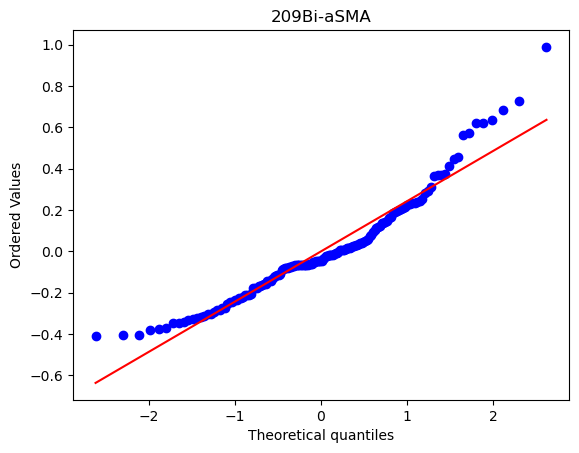

In [7]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.title(marker)
plt.show()

In [8]:
from scipy.stats import levene

stat, p = levene(*groups)
print(p)

4.2342003397753916e-05


In [14]:
from scipy.stats import shapiro
import statsmodels.api as sm

residus = F.resid

shapiro(residus)

sm.qqplot(residus, line='45')

AttributeError: 'numpy.float64' object has no attribute 'resid'

In [15]:
top_n = 10

for state in enrichment.index:
    
    print("\n================")
    print(state)
    
    ranked = (
        enrichment
        .loc[state]
        .sort_values(ascending=False)
    )
    
    print("\nTop enriched:")
    print(ranked.head(top_n))
    
    print("\nTop depleted:")
    print(ranked.tail(top_n))


('P10_S1', 'Macrophage_state_0')

Top enriched:
153Eu-CD16        0.182767
172Yb-S100A2      0.124955
143Nd-Vimentin    0.075447
159Tb-CD68        0.063466
209Bi-aSMA        0.052530
144Nd-CD14        0.034121
89Y-Collagen-I    0.021656
142Nd-CA9         0.014327
171Yb-MS4A4A      0.005324
147Sm-CD163       0.000849
Name: (P10_S1, Macrophage_state_0), dtype: float64

Top depleted:
149Sm-CD15           -0.120534
158Gd-E-Cadherin     -0.129847
173Yb-CD45RO         -0.136324
148Nd-Pan-Keratin    -0.159377
166Er-CD74           -0.176976
167Er-Granzyme_B     -0.226240
191Ir-DNA1           -0.248620
174Yb-Keratin_8_18   -0.273308
193Ir-DNA2           -0.335956
176Yb-Histone_H3     -0.422285
Name: (P10_S1, Macrophage_state_0), dtype: float64

('P10_S1', 'Macrophage_state_2')

Top enriched:
174Yb-Keratin_8_18    1.505455
196Pt-ICSK2           1.498632
148Nd-Pan-Keratin     0.960827
143Nd-Vimentin        0.786352
142Nd-CA9             0.622904
198Pt-ICSK3           0.617846
158Gd-E-Cadherin   

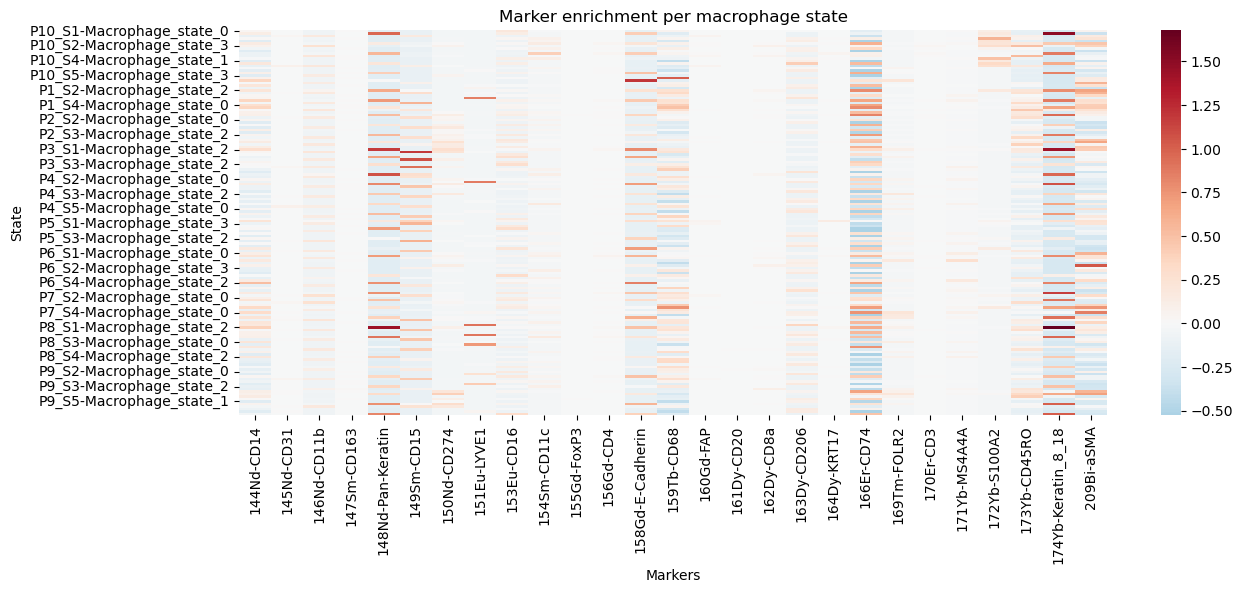

In [9]:
plt.figure(figsize=(14,5))

sns.heatmap(
    enrichment,
    cmap="RdBu_r",
    center=0,
    annot=False
)

plt.title("Marker enrichment per macrophage state")
plt.xlabel("Markers")
plt.ylabel("State")

plt.show()

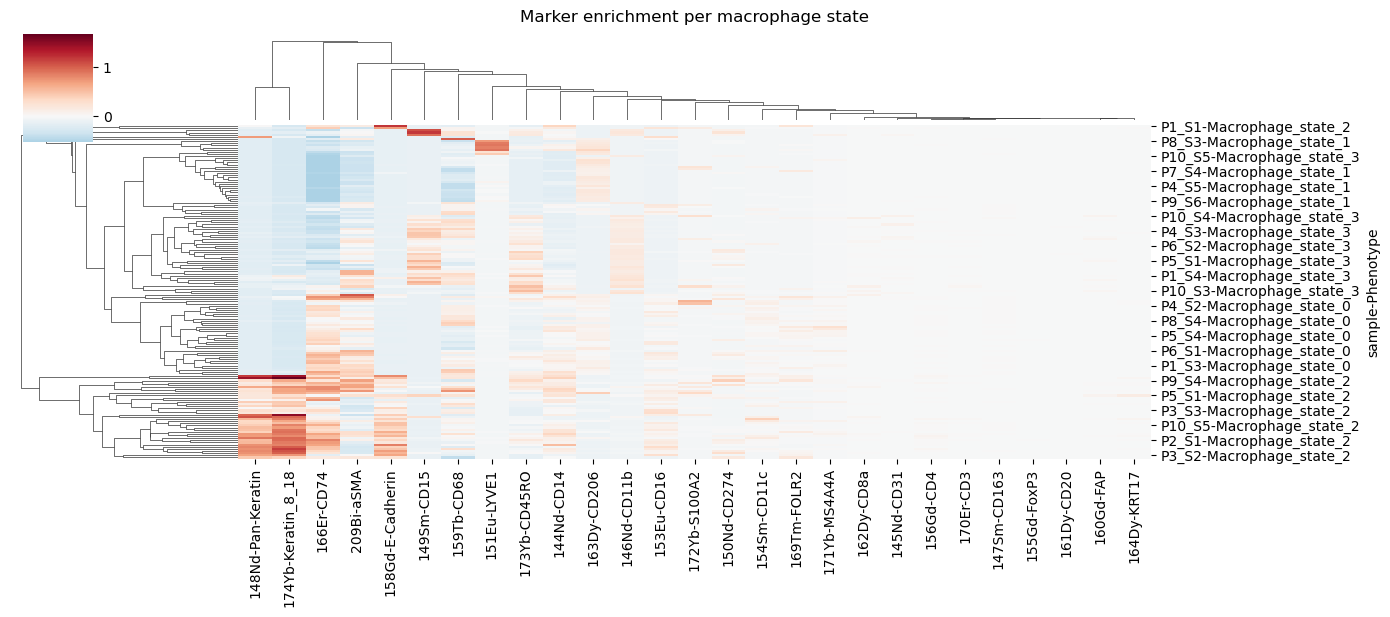

In [10]:
enrichment_state = (
    enrichment
    .groupby(level="Phenotype")
    .mean()
)

enrichment_state = enrichment

sns.clustermap(
    enrichment_state,
    cmap="RdBu_r",
    center=0,
    figsize=(14,6),
    row_cluster=True,
    col_cluster=True
)

plt.suptitle("Marker enrichment per macrophage state", y=1.02)

plt.show()

In [11]:
enrichment_state.T

sample                         P10_S1                                        \
Phenotype          Macrophage_state_0 Macrophage_state_2 Macrophage_state_3   
144Nd-CD14                   0.034121           0.123566          -0.121067   
145Nd-CD31                  -0.002959          -0.003379           0.042089   
146Nd-CD11b                 -0.062325          -0.064217           0.160214   
147Sm-CD163                  0.000849          -0.001046          -0.001046   
148Nd-Pan-Keratin           -0.159377           0.960827          -0.190230   
149Sm-CD15                  -0.120534          -0.121201           0.155599   
150Nd-CD274                 -0.040605          -0.040605          -0.040605   
151Eu-LYVE1                 -0.038501          -0.039634          -0.039634   
153Eu-CD16                   0.182767           0.121291          -0.080594   
154Sm-CD11c                 -0.017182          -0.033478          -0.033478   
155Gd-FoxP3                 -0.000029          -0.000029          -0.000029   
156Gd-CD4                   -0.004318          -0.005104          -0.005104   
158Gd-E-Cadherin            -0.129847           0.408181          -0.131711   
159Tb-CD68                   0.063466          -0.199975          -0.092874   
160Gd-FAP                   -0.002311          -0.002942           0.062275   
161Dy-CD20                  -0.000098          -0.000098          -0.000098   
162Dy-CD8a                  -0.005938          -0.005938          -0.005938   
163Dy-CD206                 -0.001286          -0.098599          -0.098599   
164Dy-KRT17                 -0.002102          -0.002102          -0.002102   
166Er-CD74                  -0.176976          -0.081129          -0.360973   
169Tm-FOLR2                 -0.026999          -0.027824          -0.027824   
170Er-CD3                   -0.000937          -0.000937          -0.000937   
171Yb-MS4A4A                 0.005324          -0.017875          -0.017875   
172Yb-S100A2                 0.124955           0.169062           0.129125   
173Yb-CD45RO                -0.136324          -0.153556           0.095387   
174Yb-Keratin_8_18          -0.273308           1.505455          -0.279805   
209Bi-aSMA                   0.052530          -0.360682           0.153947   

sample                         P10_S2                                        \
Phenotype          Macrophage_state_0 Macrophage_state_1 Macrophage_state_2   
144Nd-CD14                   0.022297          -0.201133           0.142254   
145Nd-CD31                  -0.002462          -0.003379          -0.003379   
146Nd-CD11b                 -0.059997          -0.064217          -0.038400   
147Sm-CD163                  0.000837          -0.001046          -0.001046   
148Nd-Pan-Keratin           -0.184618          -0.190230           0.129560   
149Sm-CD15                  -0.119756          -0.121201          -0.069671   
150Nd-CD274                 -0.027895          -0.040605           0.009836   
151Eu-LYVE1                 -0.037246          -0.039634          -0.039634   
153Eu-CD16                   0.034443          -0.080594           0.025406   
154Sm-CD11c                  0.094223           0.065867           0.141231   
155Gd-FoxP3                 -0.000029          -0.000029          -0.000029   
156Gd-CD4                   -0.002951          -0.005104           0.027032   
158Gd-E-Cadherin            -0.119840          -0.131711           0.218663   
159Tb-CD68                   0.049646          -0.282624           0.093380   
160Gd-FAP                   -0.001589          -0.002942           0.014722   
161Dy-CD20                   0.000035          -0.000098          -0.000098   
162Dy-CD8a                  -0.004488          -0.005938           0.008761   
163Dy-CD206                  0.084866           0.125714          -0.015603   
164Dy-KRT17                  0.000992          -0.002102           0.003417   
166Er-CD74                   0.116563          -0

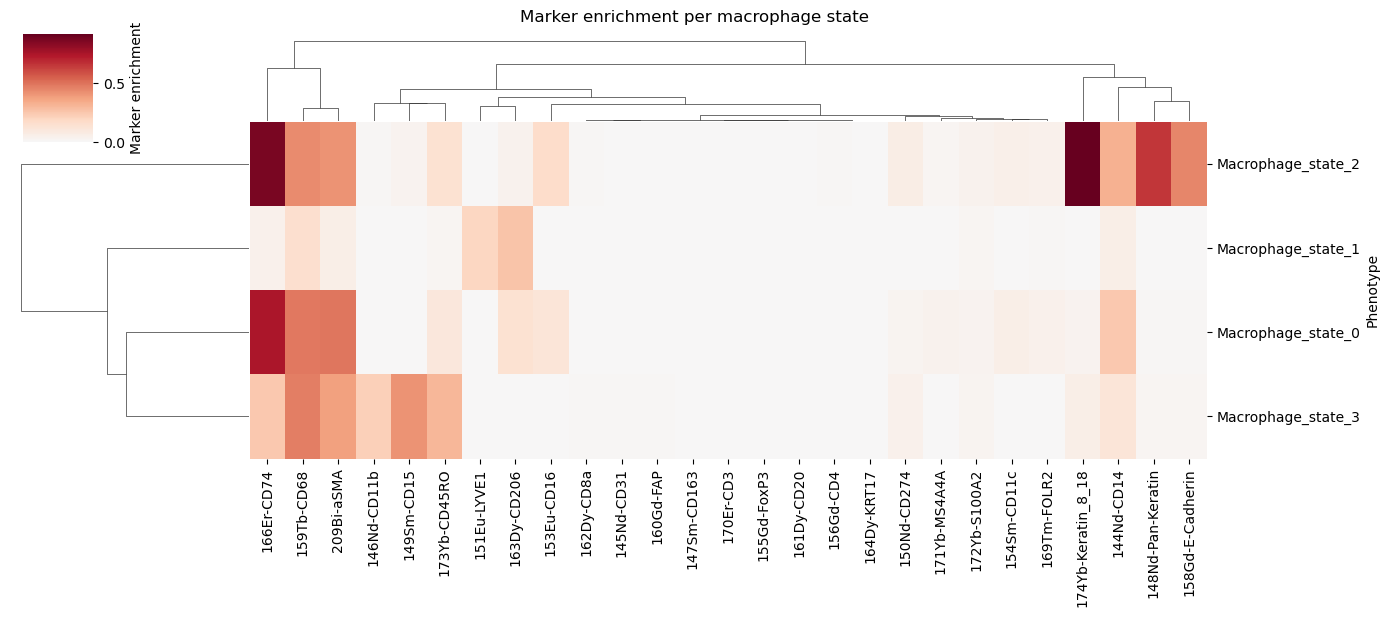

In [12]:
state_enrichment = (
    sample_df.groupby(state_col)[marker_cols]
             .mean()
)

sns.clustermap(
    state_enrichment,
    cmap="RdBu_r",
    center=0,
    figsize=(14,6),
    row_cluster=True,
    col_cluster=True,
    cbar_kws={"label": "Marker enrichment"}
)

plt.suptitle(
    "Marker enrichment per macrophage state",
    y=1.02
)

plt.show()

In [13]:
results = []

states = df[state_col].unique()


for marker in marker_cols:
    
    groups = [
        df.loc[df[state_col]==s, marker]
        for s in states
    ]
    
    stat, p = kruskal(*groups)
    
    results.append({
        "marker": marker,
        "H_stat": stat,
        "p_value": p
    })


stats_df = pd.DataFrame(results)

stats_df = stats_df.sort_values("p_value")

stats_df.head(20)

,marker,H_stat,p_value
0,144Nd-CD14,2897.444290,0.000000e+00
2,146Nd-CD11b,25163.914514,0.000000e+00
5,149Sm-CD15,19997.190945,0.000000e+00
4,148Nd-Pan-Keratin,18867.026711,0.000000e+00
6,150Nd-CD274,7764.270820,0.000000e+00
13,159Tb-CD68,1511.495358,0.000000e+00
12,158Gd-E-Cadherin,12177.769837,0.000000e+00
8,153Eu-CD16,1894.118859,0.000000e+00
24,173Yb-CD45RO,5860.226146,0.000000e+00
20,169Tm-FOLR2,5840.974645,0.000000e+00


In [14]:
from statsmodels.stats.multitest import multipletests


stats_df["FDR"] = multipletests(
    stats_df["p_value"],
    method="fdr_bh"
)[1]


stats_df.sort_values("FDR").head(20)

,marker,H_stat,p_value,FDR
0,144Nd-CD14,2897.444290,0.000000e+00,0.000000e+00
2,146Nd-CD11b,25163.914514,0.000000e+00,0.000000e+00
5,149Sm-CD15,19997.190945,0.000000e+00,0.000000e+00
4,148Nd-Pan-Keratin,18867.026711,0.000000e+00,0.000000e+00
6,150Nd-CD274,7764.270820,0.000000e+00,0.000000e+00
13,159Tb-CD68,1511.495358,0.000000e+00,0.000000e+00
12,158Gd-E-Cadherin,12177.769837,0.000000e+00,0.000000e+00
8,153Eu-CD16,1894.118859,0.000000e+00,0.000000e+00
24,173Yb-CD45RO,5860.226146,0.000000e+00,0.000000e+00
20,169Tm-FOLR2,5840.974645,0.000000e+00,0.000000e+00


In [15]:
significant_markers = (
    stats_df
    .query("FDR < 0.05")
    ["marker"]
    .tolist()
)


for marker in significant_markers:

    print("\n================")
    print(marker)

    temp = df[[state_col, marker]]

    dunn = posthoc_dunn(
        temp,
        val_col=marker,
        group_col=state_col,
        p_adjust="fdr_bh"
    )

    print(dunn)


144Nd-CD14
                    Macrophage_state_0  Macrophage_state_1  \
Macrophage_state_0        1.000000e+00        1.250237e-93   
Macrophage_state_1        1.250237e-93        1.000000e+00   
Macrophage_state_2        0.000000e+00       1.624360e-219   
Macrophage_state_3       2.045740e-137        3.125980e-17   

                    Macrophage_state_2  Macrophage_state_3  
Macrophage_state_0        0.000000e+00       2.045740e-137  
Macrophage_state_1       1.624360e-219        3.125980e-17  
Macrophage_state_2        1.000000e+00        0.000000e+00  
Macrophage_state_3        0.000000e+00        1.000000e+00  

146Nd-CD11b
                    Macrophage_state_0  Macrophage_state_1  \
Macrophage_state_0            1.000000            0.390180   
Macrophage_state_1            0.390180            1.000000   
Macrophage_state_2            0.001243            0.081093   
Macrophage_state_3            0.000000            0.000000   

                    Macrophage_state_2  Macropha

In [23]:
sample_df

,sample,Phenotype,89Y-Collagen-I,142Nd-CA9,143Nd-Vimentin,144Nd-CD14,145Nd-CD31,146Nd-CD11b,147Sm-CD163,148Nd-Pan-Keratin,...,172Yb-S100A2,173Yb-CD45RO,174Yb-Keratin_8_18,176Yb-Histone_H3,191Ir-DNA1,193Ir-DNA2,195Pt-ICSK1,196Pt-ICSK2,198Pt-ICSK3,209Bi-aSMA
0,P10_S1,Macrophage_state_0,0.051213,0.079629,0.515390,0.235254,0.000420,0.001891,0.001895,0.030853,...,0.154583,0.017233,0.006497,0.808231,0.363264,0.673408,0.278349,0.554664,0.495999,0.413212
1,P10_S1,Macrophage_state_2,0.000000,0.688206,1.226295,0.324699,0.000000,0.000000,0.000000,1.151057,...,0.198690,0.000000,1.785260,1.071445,0.404215,0.707048,0.568825,2.144463,1.226154,0.000000
2,P10_S1,Macrophage_state_3,0.064382,0.000000,0.538741,0.080066,0.045468,0.224431,0.000000,0.000000,...,0.158753,0.248943,0.000000,1.100445,0.478867,0.801121,0.394172,0.600946,0.342117,0.514629
3,P10_S2,Macrophage_state_0,0.063458,0.000963,0.277593,0.223430,0.000916,0.004219,0.001883,0.005612,...,0.608095,0.224897,0.038664,1.016154,0.336958,0.638420,0.292649,0.543651,0.456193,0.594395
4,P10_S2,Macrophage_state_1,0.099345,0.000000,0.188969,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.261444,0.000000,0.000000,0.561410,0.161573,0.570741,0.202226,0.294363,0.236229,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,P9_S5,Macrophage_state_2,0.022033,0.305000,0.301479,0.269776,0.000000,0.027094,0.000000,0.951976,...,0.000000,0.162229,1.286381,2.032395,0.668841,1.076676,0.669456,0.853458,1.172683,0.098729
152,P9_S5,Macrophage_state_3,0.000000,0.027623,0.552365,0.151860,0.012131,0.244776,0.000000,0.030405,...,0.000000,0.179204,0.100030,1.970482,0.714882,1.153116,0.434450,1.089080,0.400527,0.339458
153,P9_S6,Macrophage_state_0,0.050873,0.000000,0.242339,0.100326,0.000000,0.000000,0.001004,0.003758,...,0.000000,0.017812,0.048130,0.470157,0.342986,0.647931,0.108674,0.535581,0.312739,0.217909
154,P9_S6,Macrophage_state_1,0.118529,0.000000,0.333013,0.009326,0.009983,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.345096,0.473618,0.792321,0.019869,0.149811,0.238912,0.091060


In [165]:
state1 = "Macrophage_state_0"
state2 = "Macrophage_state_1"

# colonnes de marqueurs uniquement
markers = sample_df.columns[2:]

fc = (
    sample_df[sample_df["Phenotype"] == state1][markers].mean()
    -
    sample_df[sample_df["Phenotype"] == state2][markers].mean()
)

fc.sort_values(ascending=False).head(10)

163Dy-CD206       0.120551
159Tb-CD68        0.076100
209Bi-aSMA        0.074279
171Yb-MS4A4A      0.031142
89Y-Collagen-I    0.019723
151Eu-LYVE1       0.006336
147Sm-CD163       0.001991
145Nd-CD31        0.000033
161Dy-CD20        0.000015
155Gd-FoxP3      -0.000080
dtype: float64

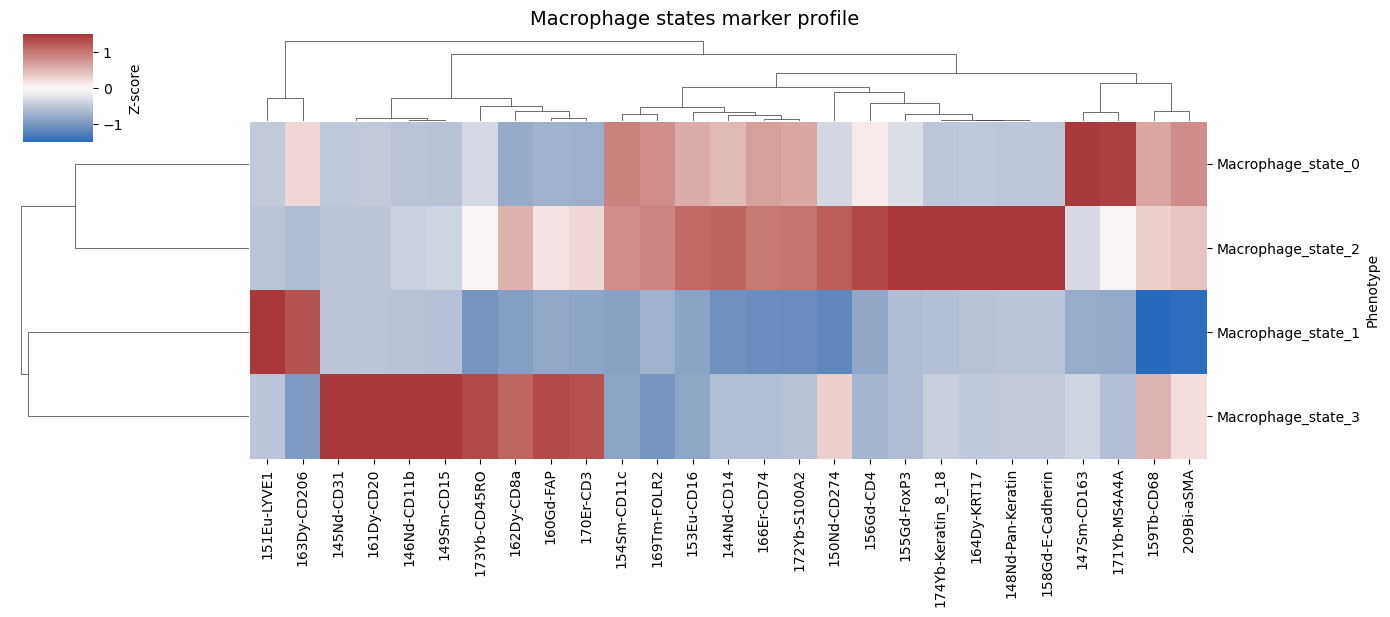

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# colonnes marqueurs uniquement
markers = sample_df.columns[2:]

# moyenne par état macrophagique
macro_mean = (
    sample_df
    .groupby("Phenotype")[markers]
    .mean()
)

# z-score par marqueur
scaled = (
    macro_mean
    .sub(macro_mean.mean(axis=0))
    .div(macro_mean.std(axis=0))
)

g = sns.clustermap(
    scaled,
    cmap="vlag",
    center=0,
    figsize=(14,6),
    annot=False,
    cbar_kws={"label": "Z-score"}
)

g.fig.suptitle(
    "Macrophage states marker profile",
    y=1.02,
    fontsize=14
)

plt.show()

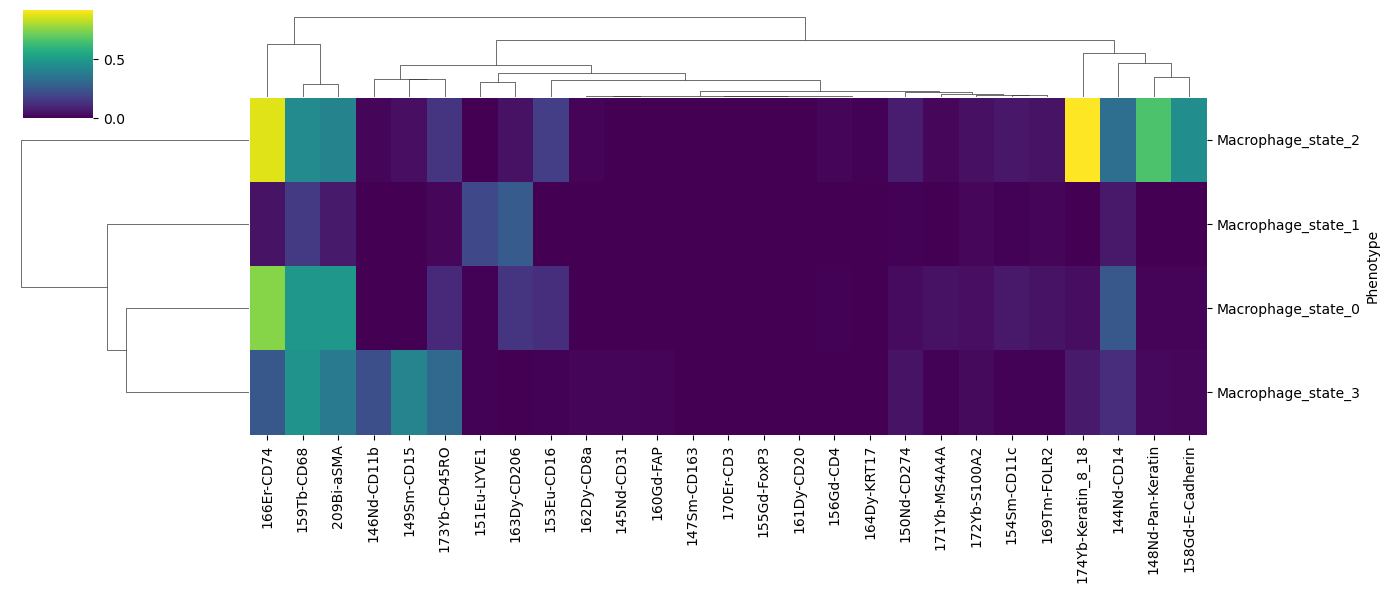

In [18]:
sns.clustermap(
    macro_mean,
    cmap="viridis",
    figsize=(14,6)
)

In [56]:
df_copy = df.copy()

In [68]:
df_copy["cell_id"]

22           P4_S1_24
72           P4_S1_76
108         P4_S1_113
115         P4_S1_120
158         P4_S1_164
             ...     
543026    P1_S3_11094
543033    P1_S3_11101
543035    P1_S3_11103
543042    P1_S3_11110
543050    P1_S3_11118
Name: cell_id, Length: 31080, dtype: object

In [88]:
df = df_copy.copy()

In [89]:
cellid_col = 'cell_id'

state_col = "Phenotype"

state1 = "Macrophage_state_2"
state2 = "Macrophage_state_1"


In [94]:
# exemple P4_S1_24

df["patient"] = (
    df["cell_id"]
    .str.extract(r"(P\d+)")
)


df["sample"] = (
    df["cell_id"]
    .str.extract(r"(P\d+_S\d+)")
)



In [91]:
marker_cols = [
    col for col in df.columns 
    if col != state_col and col != cellid_col and col != "sample" and col != "patient"
]


sample_df = (
    df
    .groupby(
        ["sample", state_col]
    )[marker_cols]
    .mean()
    .reset_index()
)



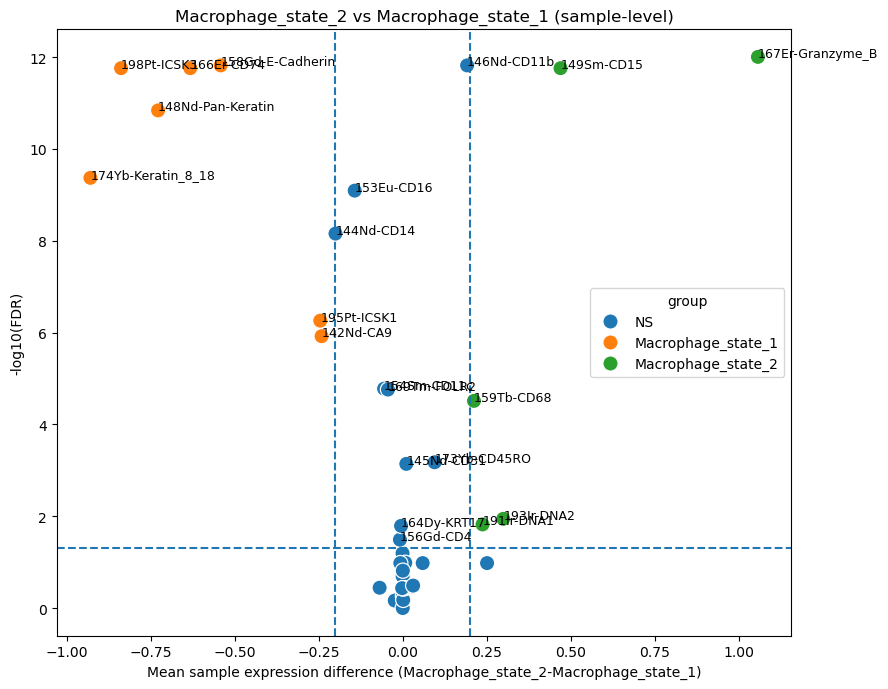

In [92]:
results=[]


for marker in marker_cols:

    group1 = sample_df.loc[
        sample_df[state_col]==state1,
        marker
    ]


    group2 = sample_df.loc[
        sample_df[state_col]==state2,
        marker
    ]


    effect = (
        group1.mean()
        -
        group2.mean()
    )


    stat,p = mannwhitneyu(
        group1,
        group2,
        alternative="two-sided"
    )


    results.append({
        "marker":marker,
        "effect":effect,
        "p_value":p
    })


volcano_df = pd.DataFrame(results)

volcano_df["FDR"] = multipletests(
    volcano_df["p_value"],
    method="fdr_bh"
)[1]

volcano_df["minus_log10_FDR"] = (
    -np.log10(volcano_df["FDR"])
)


effect_threshold = 0.2
fdr_threshold = 0.05


volcano_df["group"]="NS"


volcano_df.loc[
    (volcano_df.effect > effect_threshold)
    &
    (volcano_df.FDR < fdr_threshold),
    "group"
]=state1


volcano_df.loc[
    (volcano_df.effect < -effect_threshold)
    &
    (volcano_df.FDR < fdr_threshold),
    "group"
]=state2

plt.figure(figsize=(9,7))


sns.scatterplot(
    data=volcano_df,
    x="effect",
    y="minus_log10_FDR",
    hue="group",
    s=120
)


plt.axvline(
    effect_threshold,
    linestyle="--"
)

plt.axvline(
    -effect_threshold,
    linestyle="--"
)


plt.axhline(
    -np.log10(fdr_threshold),
    linestyle="--"
)


for _,row in volcano_df.iterrows():

    if row.FDR < 0.05:

        plt.text(
            row.effect,
            row.minus_log10_FDR,
            row.marker,
            fontsize=9
        )


plt.xlabel(
    f"Mean sample expression difference ({state1}-{state2})"
)

plt.ylabel(
    "-log10(FDR)"
)


plt.title(
    f"{state1} vs {state2} (sample-level)"
)


plt.tight_layout()

plt.show()

In [75]:
# ================================
# Librairies
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests



# ================================
# Paramètres
# ================================

state_col = "Phenotype"

state1 = "Macrophage_state_0"
state2 = "Macrophage_state_1"


# colonne ID cellule à exclure
# définir avant si besoin :
# cellid_col = "Cell_ID"

marker_cols = [
    col for col in df.columns 
    if col != state_col and col != cellid_col
]


# seuils volcano

fdr_threshold = 0.05
effect_threshold = 0.2



# ================================
# 1. Test pairwise Mann-Whitney
# ================================

results = []


for marker in marker_cols:

    group1 = df.loc[
        df[state_col] == state1,
        marker
    ]

    group2 = df.loc[
        df[state_col] == state2,
        marker
    ]


    # différence moyenne d'expression
    effect = (
        group1.mean()
        -
        group2.mean()
    )


    # Mann-Whitney U test

    stat, p_value = mannwhitneyu(
        group1,
        group2,
        alternative="two-sided"
    )


    results.append({

        "marker": marker,

        "effect": effect,

        "p_value": p_value

    })



# dataframe résultats

volcano_df = pd.DataFrame(results)



# ================================
# 2. Correction FDR
# ================================

volcano_df["FDR"] = multipletests(
    volcano_df["p_value"],
    method="fdr_bh"
)[1]



# ================================
# 3. Transformation pour volcano
# ================================

volcano_df["minus_log10_FDR"] = (
    -np.log10(volcano_df["FDR"])
)



# ================================
# 4. Classification
# ================================

volcano_df["group"] = "NS"



# enrichi dans state1

volcano_df.loc[
    (volcano_df["effect"] > effect_threshold)
    &
    (volcano_df["FDR"] < fdr_threshold),
    "group"
] = state1



# enrichi dans state2

volcano_df.loc[
    (volcano_df["effect"] < -effect_threshold)
    &
    (volcano_df["FDR"] < fdr_threshold),
    "group"
] = state2




# ================================
# 5. Volcano plot
# ================================

plt.figure(figsize=(9,7))


sns.scatterplot(
    data=volcano_df,
    x="effect",
    y="minus_log10_FDR",
    hue="group",
    s=120
)



# seuil effet

plt.axvline(
    effect_threshold,
    linestyle="--"
)


plt.axvline(
    -effect_threshold,
    linestyle="--"
)



# seuil FDR

plt.axhline(
    -np.log10(fdr_threshold),
    linestyle="--"
)



# ================================
# 6. Annotation marqueurs significatifs
# ================================

for _, row in volcano_df.iterrows():

    if row["FDR"] < fdr_threshold:

        plt.text(
            row["effect"],
            row["minus_log10_FDR"],
            row["marker"],
            fontsize=10
        )



# ================================
# 7. Labels
# ================================

plt.xlabel(
    f"Mean expression difference ({state1} - {state2})"
)


plt.ylabel(
    "-log10(FDR)"
)


plt.title(
    f"Macrophage markers: {state1} vs {state2}"
)


plt.legend(
    title="Status"
)


plt.tight_layout()

plt.show()



# ================================
# 8. Export résultats
# ================================
'''''
volcano_df.sort_values(
    "FDR"
).to_csv(
    f"volcano_MannWhitney_{state1}_vs_{state2}.csv",
    index=False
)
'''''
# ================================
# 7. Export résultats
# ================================
'''''
volcano_df.sort_values(
    "FDR"
).to_csv(
    f"volcano_{state1}_vs_{state2}.csv",
    index=False
)
'''''

TypeError: Could not convert string '...' to numeric

In [157]:
col = 'Phenotype'
stat_observed = 'markers'
group_ref = 'Macrophage_state_1'
group_tgt = 'Macrophage_state_2'


#save dir pour les plots et pvals 
path = f'./OUTPUT_arcsinh/states/leiden_states/comparaisons/{stat_observed}'
save_dir = Path(path)
save_dir.mkdir(parents=True, exist_ok=True)

In [144]:
data_comparaison = df.iloc[:,11:].copy()

data_comparaison["Phenotype"] = df["Phenotype"]


In [145]:
expr_cols = data_comparaison.columns.drop("Phenotype")

mask_ref = data_comparaison["Phenotype"] == group_ref
mask_tgt = data_comparaison["Phenotype"] == group_tgt

keep_cols = (
    (data_comparaison.loc[mask_ref, expr_cols].sum(axis=0) > 0) |
    (data_comparaison.loc[mask_tgt, expr_cols].sum(axis=0) > 0)
)

data_comparaison = data_comparaison[
    keep_cols.index[keep_cols].tolist() + ["Phenotype"]
]

In [113]:
len(data_comparaison.columns)

39

In [146]:

# tests = Kolmogorov-Smirnov et Mann-Whitney
pvals = mosna.find_DE_markers(
        data_comparaison,
        group_ref= group_ref, 
        group_tgt= group_tgt, 
        group_var=col,
        test='Mann-Whitney',
        )
if col == 'region_grouped' or col == "Phenotype":
    region = f'{group_ref}_{group_tgt}'
else :
    region= ''

pvals.to_parquet(save_dir / f'model_{stat_observed}_{col}_{region}-pvals-test-KS')
select_pvals = pvals['pval_corr'] <= 0.05
n_pvals_corr = select_pvals.sum()

In [147]:
import numpy as np

expr_cols = data_comparaison.columns.drop("Phenotype")

median_ref = (
    data_comparaison.loc[data_comparaison["Phenotype"] == group_ref, expr_cols]
    .median()
)

median_tgt = (
    data_comparaison.loc[data_comparaison["Phenotype"] == group_tgt, expr_cols]
    .median()
)

logFC = np.log2((median_tgt + 1e-6) / (median_ref + 1e-6))

pvals["logFC"] = logFC

In [148]:
# 8 plus exprimés dans group_tgt
sig = pvals[pvals["pval_corr"] < 0.05]

top_markers = pd.concat([
    sig.nlargest(10, "logFC"),
    sig.nsmallest(10, "logFC")
])

print(top_markers[["logFC", "pval_corr"]])

                        logFC      pval_corr
174Yb-Keratin_8_18  19.573210   0.000000e+00
173Yb-CD45RO        18.514194   0.000000e+00
150Nd-CD274         18.412373   0.000000e+00
148Nd-Pan-Keratin   18.248161   0.000000e+00
167Er-Granzyme_B    17.999171   0.000000e+00
158Gd-E-Cadherin    17.779552   0.000000e+00
142Nd-CA9           17.600168   0.000000e+00
169Tm-FOLR2         17.600168   0.000000e+00
195Pt-ICSK1          1.526320   0.000000e+00
198Pt-ICSK3          1.086765   0.000000e+00
159Tb-CD68          -1.039954   0.000000e+00
163Dy-CD206          0.000000   0.000000e+00
89Y-Collagen-I       0.000000  3.337444e-143
154Sm-CD11c          0.000000  1.998570e-141
145Nd-CD31           0.000000   4.351401e-99
153Eu-CD16           0.000000   6.246516e-95
172Yb-S100A2         0.000000   5.956781e-89
164Dy-KRT17          0.000000   8.195528e-36
171Yb-MS4A4A         0.000000   5.262442e-23
149Sm-CD15           0.000000   1.098325e-20


In [149]:
markers = top_markers.index.tolist()

plot_df = data_comparaison[
    data_comparaison["Phenotype"].isin([group_ref, group_tgt])
][markers + ["Phenotype"]]

In [150]:
plot_df.columns

Index(['174Yb-Keratin_8_18', '173Yb-CD45RO', '150Nd-CD274',
       '148Nd-Pan-Keratin', '167Er-Granzyme_B', '158Gd-E-Cadherin',
       '142Nd-CA9', '169Tm-FOLR2', '195Pt-ICSK1', '198Pt-ICSK3', '159Tb-CD68',
       '163Dy-CD206', '89Y-Collagen-I', '154Sm-CD11c', '145Nd-CD31',
       '153Eu-CD16', '172Yb-S100A2', '164Dy-KRT17', '171Yb-MS4A4A',
       '149Sm-CD15', 'Phenotype'],
      dtype='object')

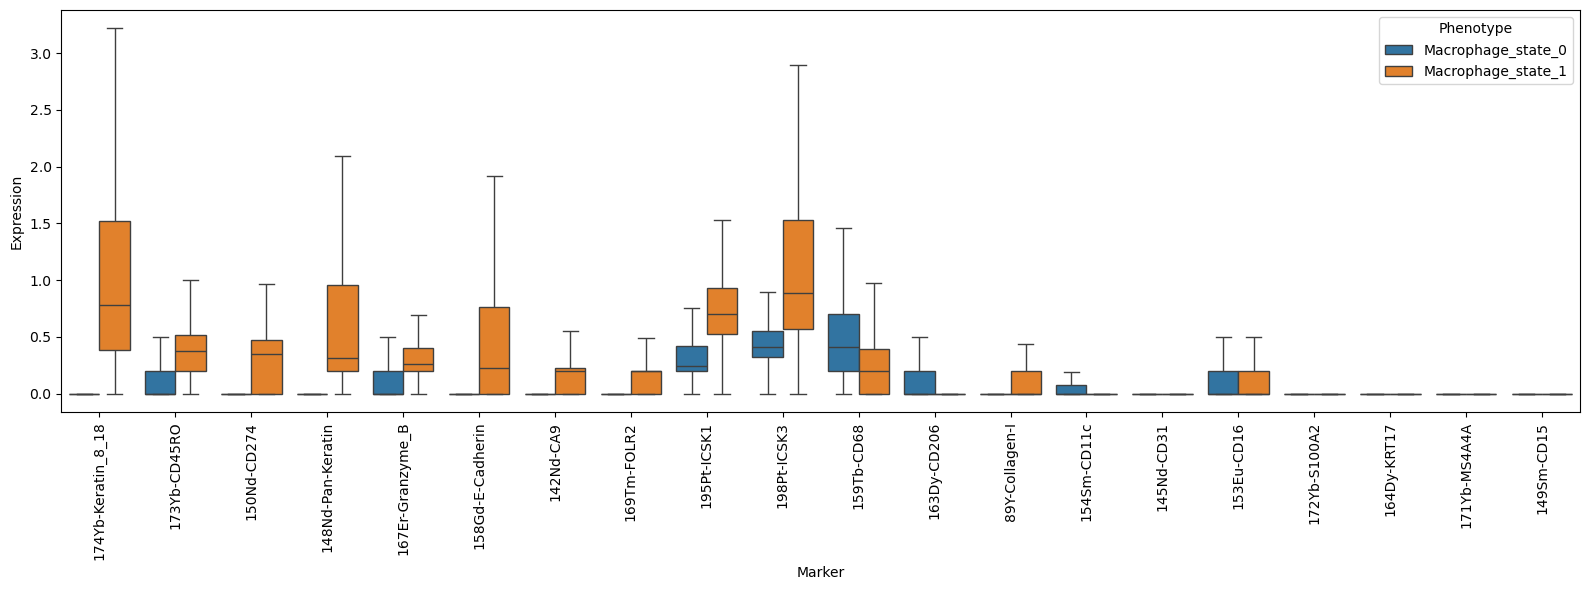

In [151]:
# Boxplots

# Format long
plot_df = plot_df.melt(
    id_vars="Phenotype",
    var_name="Marker",
    value_name="Expression"
)
plt.figure(figsize=(16, 6))
sns.boxplot(
    data=plot_df,
    x="Marker",
    y="Expression",
    hue="Phenotype",
    showfliers=False
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [158]:
import pandas as pd
import numpy as np

# ============================
# 1) Préparer les données
# ============================

data_comparaison = df.iloc[:, 11:].copy()
data_comparaison["Phenotype"] = df["Phenotype"]

expr_cols = data_comparaison.columns.drop("Phenotype")


# ============================
# 2) Test DE Mann-Whitney
# ============================

pvals = mosna.find_DE_markers(
    data_comparaison,
    group_ref=group_ref,
    group_tgt=group_tgt,
    group_var="Phenotype",
    test="Mann-Whitney",
)


# ============================
# 3) Calcul des statistiques d'expression
# ============================

ref_mask = data_comparaison["Phenotype"] == group_ref
tgt_mask = data_comparaison["Phenotype"] == group_tgt

stats = pd.DataFrame(index=pvals.index)


# Médianes (adapté aux données arcsinh)
stats["median_ref"] = (
    data_comparaison.loc[ref_mask, expr_cols]
    .median()
)

stats["median_tgt"] = (
    data_comparaison.loc[tgt_mask, expr_cols]
    .median()
)


# Différence de médiane
# positif = plus exprimé dans target
# négatif = plus exprimé dans ref
stats["delta_median"] = (
    stats["median_tgt"] -
    stats["median_ref"]
)


# Moyennes (optionnel, pour information)
stats["mean_ref"] = (
    data_comparaison.loc[ref_mask, expr_cols]
    .mean()
)

stats["mean_tgt"] = (
    data_comparaison.loc[tgt_mask, expr_cols]
    .mean()
)


# Pourcentage de cellules positives
stats["pct_ref"] = (
    data_comparaison.loc[ref_mask, expr_cols] > 0
).mean()

stats["pct_tgt"] = (
    data_comparaison.loc[tgt_mask, expr_cols] > 0
).mean()


# Ajouter les p-values
stats["pval"] = pvals["pval"]
stats["pval_corr"] = pvals["pval_corr"]



# ============================
# 4) Catégorie 1 :
# marqueurs spécifiques TARGET
# ============================

specific_tgt = stats[
    (stats["pct_tgt"] > 0.5) &
    (stats["pct_ref"] < 0.1)
].sort_values(
    "delta_median",
    ascending=False
)



# ============================
# 5) Catégorie 2 :
# marqueurs spécifiques REF
# ============================

specific_ref = stats[
    (stats["pct_ref"] > 0.5) &
    (stats["pct_tgt"] < 0.1)
].sort_values(
    "delta_median",
    ascending=True
)



# ============================
# 6) Catégorie 3 :
# marqueurs modulés
# ============================

modulated = stats[
    (stats["pct_ref"] >= 0.1) &
    (stats["pct_tgt"] >= 0.1)
].sort_values(
    "delta_median",
    ascending=False
)



# ============================
# 7) Sauvegarde
# ============================
'''''
specific_tgt.to_csv(
    "markers_specific_target.csv"
)

specific_ref.to_csv(
    "markers_specific_ref.csv"
)

modulated.to_csv(
    "markers_modulated.csv"
)
'''''


# ============================
# 8) Affichage résumé
# ============================

print("Markers spécifiques TARGET")
display(
    specific_tgt.head(20)
)

print("Markers spécifiques REF")
display(
    specific_ref.head(20)
)

print("Markers modulés")
display(
    modulated.head(20)
)

Markers spécifiques TARGET


,median_ref,median_tgt,delta_median,mean_ref,mean_tgt,pct_ref,pct_tgt,pval,pval_corr
149Sm-CD15,0.0,0.399674,0.399674,0.005665,0.464421,0.015281,0.864615,0.0,0.0
146Nd-CD11b,0.0,0.198690,0.198690,0.003703,0.217584,0.017353,0.935385,0.0,0.0


Markers spécifiques REF


,median_ref,median_tgt,delta_median,mean_ref,mean_tgt,pct_ref,pct_tgt,pval,pval_corr
158Gd-E-Cadherin,0.224997,0.0,-0.224997,0.447749,0.011427,0.588967,0.049846,2.968577e-291,8.057567e-291
142Nd-CA9,0.198690,0.0,-0.198690,0.221327,0.008412,0.692567,0.040615,0.000000e+00,0.000000e+00
169Tm-FOLR2,0.198690,0.0,-0.198690,0.157407,0.002691,0.684020,0.011077,0.000000e+00,0.000000e+00


Markers modulés


,median_ref,median_tgt,delta_median,mean_ref,mean_tgt,pct_ref,pct_tgt,pval,pval_corr
167Er-Granzyme_B,0.261992,1.223916,0.961923,0.275533,1.291733,0.766900,1.000000,0.000000e+00,0.000000e+00
159Tb-CD68,0.198690,0.592517,0.393826,0.263546,0.650722,0.709402,0.996923,0.000000e+00,0.000000e+00
196Pt-ICSK2,0.769179,0.731731,-0.037448,0.835859,0.767266,0.997928,0.995077,1.212634e-07,1.588969e-07
144Nd-CD14,0.284353,0.198690,-0.085662,0.323570,0.135049,0.969956,0.564308,0.000000e+00,0.000000e+00
209Bi-aSMA,0.460546,0.352645,-0.107901,0.757101,0.450586,0.794872,0.820923,4.439678e-22,7.029490e-22
173Yb-CD45RO,0.374392,0.248630,-0.125762,0.352761,0.300091,0.832427,0.828308,2.201438e-15,3.346186e-15
143Nd-Vimentin,0.581815,0.390128,-0.191687,0.645723,0.469090,0.867910,0.878769,3.305008e-27,5.460448e-27
191Ir-DNA1,0.978702,0.746662,-0.232039,0.943697,0.780250,0.976172,0.983385,7.015036e-44,1.403007e-43
193Ir-DNA2,1.512772,1.224457,-0.288316,1.437580,1.240720,0.994043,0.998154,4.658894e-41,8.430380e-41
148Nd-Pan-Keratin,0.311345,0.000000,-0.311345,0.628377,0.038162,0.776224,0.128000,0.000000e+00,0.000000e+00


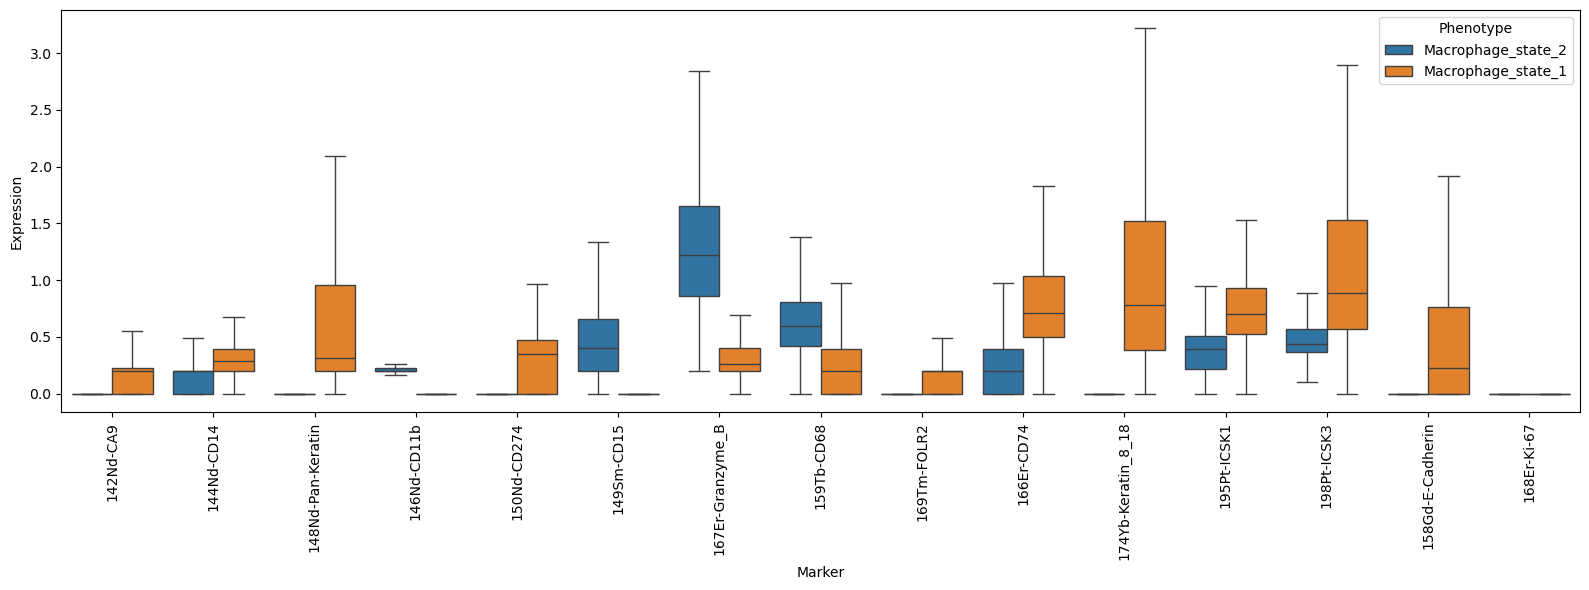

In [159]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Top 15 marqueurs les plus significatifs
top15 = pvals.nsmallest(15, "pval_corr").index.tolist()

# Garder uniquement ces marqueurs + la condition

plot_df = data_comparaison[
    data_comparaison["Phenotype"].isin([group_ref, group_tgt])
][top15 + ["Phenotype"]]

# Format long
plot_df = plot_df.melt(
    id_vars="Phenotype",
    var_name="Marker",
    value_name="Expression"
)

# Boxplots
plt.figure(figsize=(16, 6))
sns.boxplot(
    data=plot_df,
    x="Marker",
    y="Expression",
    hue="Phenotype",
    showfliers=False
)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [120]:
top15 = pvals.nsmallest(15, "pval_corr").index
plot_df = data_comparaison[
    data_comparaison["Phenotype"].isin([group_ref, group_tgt])
][top15 + ["Phenotype"]]

heatmap = (
    plot_df
    .groupby("Phenotype")[top15]
    .mean()
)

sns.clustermap(
    heatmap,
    cmap="viridis",
    standard_scale=1,   # normalise chaque marqueur
)

KeyError: "None of [Index(['142Nd-CA9Phenotype', '144Nd-CD14Phenotype',\n       '148Nd-Pan-KeratinPhenotype', '146Nd-CD11bPhenotype',\n       '150Nd-CD274Phenotype', '149Sm-CD15Phenotype',\n       '167Er-Granzyme_BPhenotype', '159Tb-CD68Phenotype',\n       '169Tm-FOLR2Phenotype', '166Er-CD74Phenotype',\n       '174Yb-Keratin_8_18Phenotype', '195Pt-ICSK1Phenotype',\n       '198Pt-ICSK3Phenotype', '158Gd-E-CadherinPhenotype',\n       '168Er-Ki-67Phenotype'],\n      dtype='object')] are in the [columns]"

In [114]:
marker = "144Nd-CD14"

print(data_comparaison.loc[data_comparaison["Phenotype"] == group_ref, marker].describe())
print(data_comparaison.loc[data_comparaison["Phenotype"] == group_tgt, marker].describe())

count    3861.000000
mean        0.323570
std         0.165754
min         0.000000
25%         0.198690
50%         0.284353
75%         0.390407
max         1.503743
Name: 144Nd-CD14, dtype: float64
count    1625.000000
mean        0.135049
std         0.156113
min         0.000000
25%         0.000000
50%         0.198690
75%         0.198690
max         2.027680
Name: 144Nd-CD14, dtype: float64


In [101]:
pvals

,pval,pval_corr
142Nd-CA9,0.000000e+00,0.000000e+00
144Nd-CD14,0.000000e+00,0.000000e+00
148Nd-Pan-Keratin,0.000000e+00,0.000000e+00
146Nd-CD11b,0.000000e+00,0.000000e+00
150Nd-CD274,0.000000e+00,0.000000e+00
149Sm-CD15,0.000000e+00,0.000000e+00
167Er-Granzyme_B,0.000000e+00,0.000000e+00
159Tb-CD68,0.000000e+00,0.000000e+00
169Tm-FOLR2,0.000000e+00,0.000000e+00
166Er-CD74,0.000000e+00,0.000000e+00


In [99]:
select_pvals

142Nd-CA9              True
144Nd-CD14             True
148Nd-Pan-Keratin      True
146Nd-CD11b            True
150Nd-CD274            True
149Sm-CD15             True
167Er-Granzyme_B       True
159Tb-CD68             True
169Tm-FOLR2            True
166Er-CD74             True
174Yb-Keratin_8_18     True
195Pt-ICSK1            True
198Pt-ICSK3            True
158Gd-E-Cadherin       True
168Er-Ki-67            True
153Eu-CD16             True
89Y-Collagen-I         True
172Yb-S100A2           True
191Ir-DNA1             True
171Yb-MS4A4A           True
193Ir-DNA2             True
176Yb-Histone_H3       True
143Nd-Vimentin         True
209Bi-aSMA             True
173Yb-CD45RO           True
154Sm-CD11c            True
162Dy-CD8a             True
160Gd-FAP              True
196Pt-ICSK2            True
164Dy-KRT17            True
170Er-CD3              True
163Dy-CD206            True
156Gd-CD4              True
147Sm-CD163           False
155Gd-FoxP3           False
151Eu-LYVE1         

There are 33 significant variables in `pval_corr`


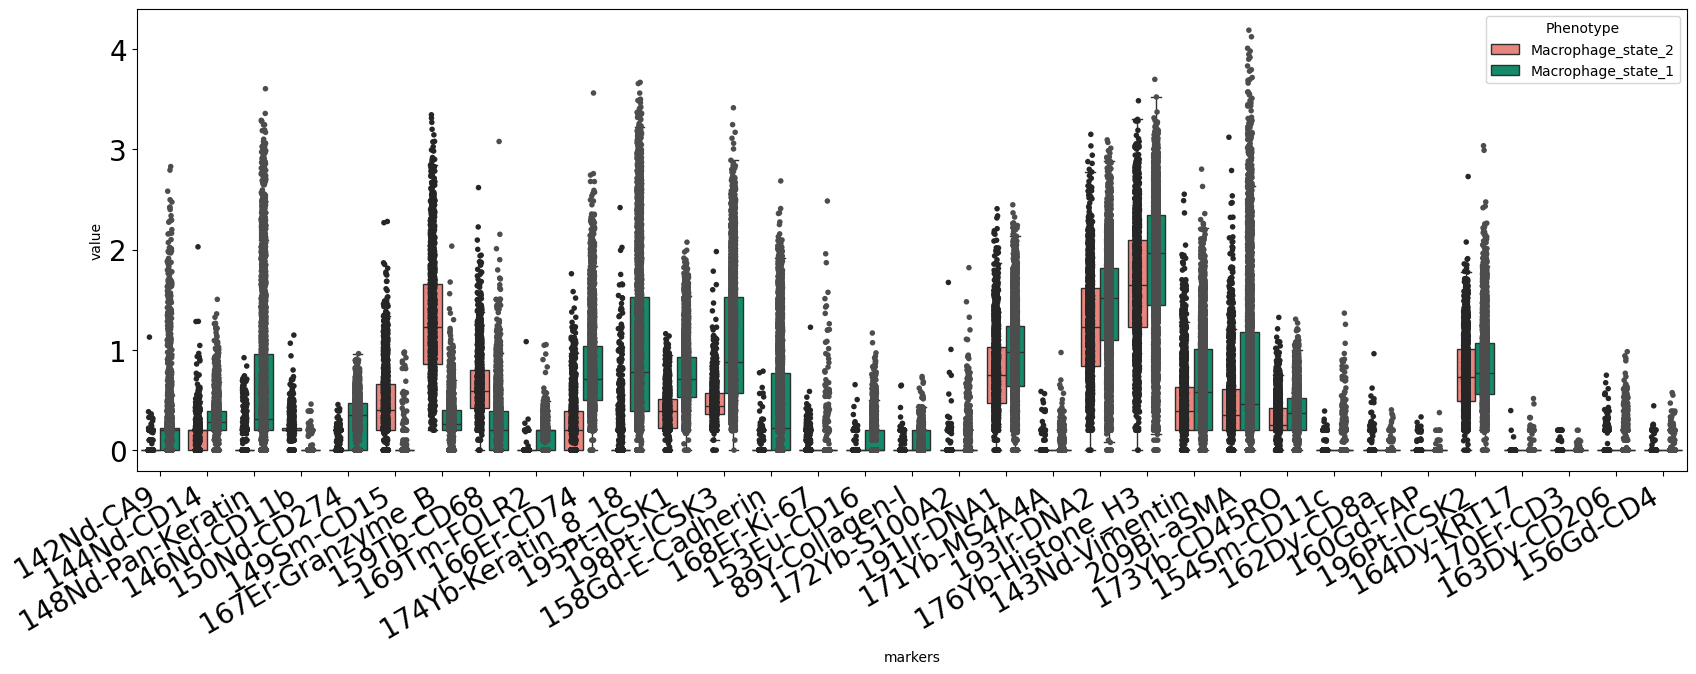

In [98]:
fig, ax = mosna.plot_distrib_groups(
    data_comparaison, 
    group_var=col,
    groups=[group_ref, group_tgt], 
    pval_data=pvals,
    pval_col='pval_corr',
    var_name=stat_observed
)
if col == 'region_grouped' or col == "Phenotype":
    region = f'{group_ref}_{group_tgt}'
else :
    region= ''
plt.savefig(save_dir / f'{stat_observed}_comparaison_{col}_{region}', bbox_inches='tight', facecolor='white', dpi=150)
plt.show()

## CD8 exclusion

In [214]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
from time import time
from pathlib import Path
import copy


from umap import UMAP
import leidenalg as la

import anndata as ad
import scanpy as sc

### Paramètres et données

### Fonctions

In [220]:
def pourcentage_only(index_col,data):
    #je choisis que les colonnes z score et je retire la colonne "assort Z"
    databar = []
    colonnes_pourcentage = [col for col in stats_data.columns if col.startswith("%")]
    data_bar = data[[index_col, "region_grouped"] + colonnes_pourcentage]
    return data_bar



In [221]:
# colonne id = colonne patient_sample

def Z_scores_only(stats_data):
    #je choisis que les colonnes z score et je retire la colonne "assort Z"
    heatmap = []
    colonnes_Z = [col for col in stats_data.columns if col.endswith("Z")]
    data_heatmap = stats_data[["id"] + colonnes_Z]
    data_heatmap = data_heatmap.drop(columns ="assort Z")
    return data_heatmap

def Z_scores_only_index(stats_data):
    #je choisis que les colonnes z score et je retire la colonne "assort Z"
    
    heatmap = []
    id_col = "id" if "id" in stats_data.columns else stats_data.columns[0]

    colonnes_Z = [col for col in stats_data.columns if col.endswith("Z")]

    data_heatmap = stats_data[[id_col] + colonnes_Z].copy()

    data_heatmap = data_heatmap.drop(columns=["assort Z"], errors="ignore")
    
    return data_heatmap


def données_ligne_en_matrice(data):
#Je prend les données de mosna.groups_assort_mixmat avec seulement les z scores et la colonne id et j'en fais une matrice 
    cols = data.columns
    vals = data.iloc[0]

    df = pd.DataFrame({
        "interaction": cols,
        "Z": vals.values
    })
    
    df["interaction"] = df["interaction"].str.replace(" Z", "", regex=False)
    df[["source", "target"]] = df["interaction"].str.split(" - ", expand=True)
    
    mat = df.pivot(index="source", columns="target", values="Z")
    mat = mat.apply(pd.to_numeric, errors="coerce")

    return mat


def heatmap(data_heatmap,chemin, diag= True):
##fonction pour enregistrer toutes les heatmaps dans un dossier path = chemin
# data_heatmap c'est les données de mosna.groups_assort_mixmat avec seulement les z scores et la colonne id je vais en faire une matrice et une heat map 
# diag = bool, par défaut = True, si =false, ça va retirer la diagonale dans la heat map
    for i in range(len(data_heatmap)):
        temp = data_heatmap.iloc[[i]]
        sample = temp["id"].iloc[0]
        temp = temp.drop(columns="id")
        
        
        matrice = données_ligne_en_matrice(temp)
        matrice = matrice.combine_first(matrice.T)
        if diag == False :
            np.fill_diagonal(matrice.values, np.nan)
            matrice = matrice.combine_first(matrice.T)

        matrice = matrice.replace([np.inf, -np.inf], 0)
        fig = plt.figure(figsize=(12, 10))
        ax = sns.heatmap(matrice, cmap="coolwarm", center=0)
        ax.set_title(f"Heatmap {sample}")
        
        enregistrement = os.path.join(chemin,f'heatmap {sample}')

        plt.savefig(enregistrement,bbox_inches="tight")
        plt.close(fig)

def heatmap_index(data_heatmap,chemin, diag= True):
##fonction pour enregistrer toutes les heatmaps dans un dossier path = chemin
# data_heatmap c'est les données de mosna.groups_assort_mixmat avec seulement les z scores et la colonne id je vais en faire une matrice et une heat map 
# diag = bool, par défaut = True, si =false, ça va retirer la diagonale dans la heat map
    for i in range(len(data_heatmap)):
        temp = data_heatmap.iloc[[i]]
        sample = temp["index"].iloc[0]
        temp = temp.drop(columns="index")
        
        
        matrice = données_ligne_en_matrice(temp)
        matrice = matrice.combine_first(matrice.T)
        if diag == False :
            np.fill_diagonal(matrice.values, np.nan)
            matrice = matrice.combine_first(matrice.T)

        matrice = matrice.replace([np.inf, -np.inf], 0)
        fig = plt.figure(figsize=(12, 10))
        ax = sns.heatmap(matrice, cmap="coolwarm", center=0)
        ax.set_title(f"Heatmap {sample}")
        
        enregistrement = os.path.join(chemin,f'heatmap {sample}')

        plt.savefig(enregistrement)
        plt.close(fig)

#def tableau_heatmap(data_heatmap,chemin):
    



In [222]:


# récup stats data sans le générer
save_dir = Path("./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/assortativity/500_shuffles")
stats_data = pd.read_parquet(save_dir / "group_stats_data_assortativity.parquet")

#je récup métainfos
info_metadata_path = Path('./images_metadatainfo.csv')
metadata = pd.read_csv(info_metadata_path)

In [223]:
#Je recupère patient et sample en pour chaque ligne de metainfo data et je mets ça dans colonne image sachant que de la forme 4 derniers chiffre = 2 premiers patient, deux derniere sample

import re
metadata = metadata.copy()

metadata["patient"] = metadata["image"].str[6:8]
metadata["sample"] = metadata["image"].str[8:10]

metadata["id"] = "patient-" + metadata["patient"] + "_sample-" + metadata["sample"]


metadata = metadata.set_index('id')

metadata.index = (
    metadata.index
    .astype(str)
    .map(
        lambda x: re.sub(r'(\D)0+(\d+)', r'\1\2', x)
    )
)

metadata.head()

,image,width_px,height_px,num_channels,source_file,recovery_file,recovered,original image ID,Notes,Patient ID,For tumour only analysis,Pathology,Stage,Grade,Location in pancrea,Treatment before tissue collection,Diabetes,Pancreatitis,patient,sample
id,,,,,,,,,,,,,,,,,,,,
patient-1_sample-3,hPDAC_0103,1968,1089,38,S0868_M Chihara-Slide_01_Dysplasia_x32670_y119...,NaN,False,S0868_M Chihara-Slide_01_Dysplasia_x32670_y119...,dysplasia,A22TLYZ04-01,No,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,03
patient-1_sample-4,hPDAC_0104,1395,1578,38,S0868_M Chihara-Slide_01_adjacent normal_x1679...,NaN,False,S0868_M Chihara-Slide_01_adjacent normal_x1679...,adjacent normal,A22TLYZ04-01,No,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,04
patient-1_sample-2,hPDAC_0102,1395,1578,38,S0868_M Chihara-Slide_01_adjacent stroma_x2139...,NaN,False,S0868_M Chihara-Slide_01_adjacent stroma_x2139...,tumour stroma,A22TLYZ04-01,Yes,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,02
patient-1_sample-1,hPDAC_0101,1439,1534,38,S0868_M Chihara-Slide_01_tumour centre_x20222_...,NaN,False,S0868_M Chihara-Slide_01_tumour centre_x20222_...,tumour centre,A22TLYZ04-01,Yes,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,01
patient-2_sample-3,hPDAC_0203,1432,1472,38,S0869_M Chihara-Slide_02_adjacent stroma_1_x31...,NaN,False,S0869_M Chihara-Slide_02_adjacent stroma_1_x31...,tumour stroma,A22TLYZ04-02,Yes,Moderately differentiated ductal carcinoma,III,2,Head,"Yes, chemotherapy",No,No,02,03


In [224]:
#je récupère net_stat = stats_data (données stats assort) mais avec localisation précisée (region_grouped)

net_stat = stats_data.copy()

net_stat = net_stat.set_index('id')
net_stat = net_stat.join(metadata, how='inner')
#on standarise les noms de pathologie pour éviter les problèmes de mapping, parfois poorly est écrit avec un p minuscule et parfois avec un P majuscule.
net_stat['Pathology'] = net_stat['Pathology'].map({
    'Moderately differentiated ductal carcinoma':'Moderately differentiated ductal carcinoma',
    'Poorly differentiated ductal carcinoma':'Poorly differentiated ductal carcinoma',
    'poorly differentiated ductal carcinoma':'Poorly differentiated ductal carcinoma'})
mapping = {
    'tumour': 'Tumour',
    'tumour centre': 'Tumour',
    'tumour_invasive area': 'Tumour',
    'tumour + islets': 'Tumour',
    'tumour incl. stroma and islets': 'Tumour',
    'tumor intraductal spread': 'Tumour',

    'tumour stroma': 'Tumour_stroma',
    'adjacent stroma': 'Tumour_stroma',

    'dysplasia': 'Dysplasia',
    'dysplasia + islets': 'Dysplasia',

    'adjacent normal': 'Adjacent_normal'
}
net_stat['region_grouped'] = net_stat['Notes'].map(mapping)
net_stat = net_stat.reset_index()

net_stat.head()


,id,# total,% B Cell,% CAF,% CD4 T Cell,% CD8 T Cell,% DC,% Endothelial Cell,% Epithelial Cell,% Macrophage_state_0,...,Pathology,Stage,Grade,Location in pancrea,Treatment before tissue collection,Diabetes,Pancreatitis,patient,sample,region_grouped
0,patient-4_sample-1,14836,0.002090,0.419790,0.057900,0.023659,0.017525,0.047250,0.003235,0.028647,...,Poorly differentiated ductal carcinoma,IIB,3,Neck,No,Yes,No,04,01,Tumour
1,patient-9_sample-4,10252,0.001171,0.112173,0.010827,0.065938,0.014534,0.000488,0.107979,0.009559,...,Moderately differentiated ductal carcinoma,IIB,2,Head/Neck,No,Yes,No,09,04,Dysplasia
2,patient-4_sample-5,17576,0.000341,0.182920,0.012745,0.027139,0.008307,0.001195,0.555473,0.025148,...,Poorly differentiated ductal carcinoma,IIB,3,Neck,No,Yes,No,04,05,Adjacent_normal
3,patient-1_sample-4,17213,0.003079,0.272759,0.064777,0.065358,0.014756,0.006971,0.375356,0.037936,...,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,04,Adjacent_normal
4,patient-8_sample-2,13913,0.001509,0.422051,0.046360,0.039675,0.012578,0.008553,0.001509,0.067060,...,Poorly differentiated ductal carcinoma,IIB,3,Neck/Body,No,Yes,Not confirmed,08,02,Tumour


## Analyse

In [229]:
save_dir_plot = Path("./OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/leiden_states/assortativity/500_shuffles/specific_abundance_analisis")
save_dir_plot.mkdir(exist_ok = True)

In [246]:
#palette prédéfinie manuellement
location_to_color = {
'Tumour_stroma': (1.0, 1.0, 0.7019607843137254) ,
'Tumour': (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
'Dysplasia':(0.5529411764705883, 0.8274509803921568, 0.7803921568627451) ,
'Adjacent_normal':(0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
"High DP" :(0.984313725490196, 0.5019607843137255, 0.4470588235294118),
"Low DP": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
}

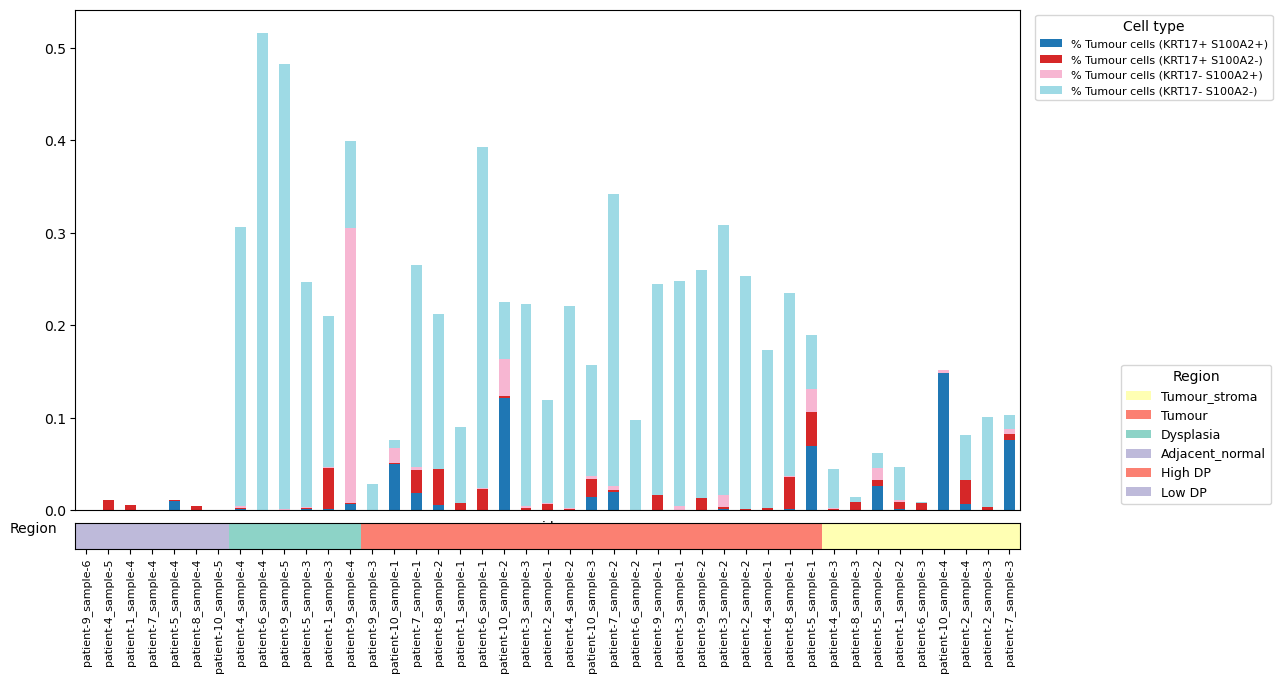

In [279]:


#abundance plot
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch

data_bar = pourcentage_only("id", net_stat)
tumour_cols = data_bar.filter(regex=r"^% Tumour cells")
data_bar = data_bar[["id", "region_grouped"] + tumour_cols.columns.tolist()]

# --------- figure avec 2 axes ---------
fig = plt.figure(figsize=(18,7))
gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[20, 1],
    hspace=0.05
)

ax = fig.add_subplot(gs[0])
ax_loc = fig.add_subplot(gs[1])

# --------- stacked barplot ---------

# alignement selon region

data_bar = data_bar.sort_values("region_grouped")

(
    data_bar
    .set_index("id")
    .drop(columns=["region_grouped"])
    .plot(
        kind="bar",
        stacked=True,
        cmap="tab20",
        ax=ax
    )
)

# --------- localisation ---------
location_series = (
    net_stat
    .set_index("id")
    .loc[data_bar["id"], "region_grouped"]
)

unique_locations = location_series.dropna().unique()

'''
palette = sns.color_palette(
    "Set3",
    n_colors=len(unique_locations)
)

location_to_color = dict(
    zip(unique_locations, palette)
)
'''

if location_to_color == None:
    palette = sns.color_palette("Set3", n_colors=len(unique_locations))
    location_to_color = dict(zip(unique_locations, palette))

    
location_to_int = {
    loc: i
    for i, loc in enumerate(unique_locations)
}

location_ints = np.array([
    location_to_int.get(loc, -1)
    for loc in location_series
])

location_cmap = ListedColormap(
    [location_to_color[loc] for loc in unique_locations]
)

ax_loc.imshow(
    location_ints[np.newaxis, :],
    aspect="auto",
    cmap=location_cmap,
    interpolation="nearest"
)

ax_loc.set_yticks([])
ax_loc.set_ylabel(
    "Region",
    rotation=0,
    labelpad=30
)



# enlever labels du barplot
ax.set_xticklabels([])
ax.tick_params(axis="x", length=0)

# labels uniquement sur ax_loc
ax_loc.set_xticks(np.arange(len(location_ints)))
ax_loc.set_xticklabels(
    data_bar["id"],
    rotation=90,
    fontsize=8
)



# synchronisation (très important)
ax_loc.set_xlim(ax.get_xlim())

# -----------------------------
# LÉGENDE CELL TYPES (coin supérieur droit)
# -----------------------------
cell_legend = ax.legend(
    title="Cell type",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    fontsize=8
)

ax.add_artist(cell_legend)

# -----------------------------
# LÉGENDE REGIONS (coin inférieur droit)
# -----------------------------
region_handles = [
    Patch(facecolor=color, label=region)
    for region, color in location_to_color.items()
]

ax.legend(
    handles=region_handles,
    title="Region",
    loc="lower left",
    bbox_to_anchor=(1.1, 0.0),
    frameon=True,
    fontsize=9
)



# laisser de la place à droite
plt.subplots_adjust(right=0.65)

plt.savefig(save_dir_plot / "tumor_status_abondance.png", bbox_inches="tight")
plt.show()

In [251]:
location_series

id
patient-8_sample-2     High DP
patient-7_sample-1     High DP
patient-10_sample-3    High DP
patient-7_sample-2     High DP
patient-10_sample-2    High DP
patient-3_sample-2     High DP
patient-10_sample-1    High DP
patient-5_sample-1     High DP
patient-4_sample-1      Low DP
patient-1_sample-1      Low DP
patient-6_sample-1      Low DP
patient-2_sample-1      Low DP
patient-6_sample-2      Low DP
patient-2_sample-2      Low DP
patient-9_sample-3      Low DP
patient-4_sample-2      Low DP
patient-3_sample-1      Low DP
patient-9_sample-2      Low DP
patient-3_sample-3      Low DP
patient-9_sample-1      Low DP
patient-8_sample-1      Low DP
patient-9_sample-4         NaN
patient-4_sample-5         NaN
patient-1_sample-4         NaN
patient-7_sample-3         NaN
patient-10_sample-5        NaN
patient-8_sample-4         NaN
patient-10_sample-4        NaN
patient-5_sample-3         NaN
patient-4_sample-3         NaN
patient-6_sample-3         NaN
patient-4_sample-4         NaN
patie

In [273]:
import numpy as np

col = "% Tumour cells (KRT17+ S100A2+)"

tumour = data_bar[data_bar["region_grouped"] == "Tumour"].copy()

threshold = tumour[col].median(skipna=True)

tumour["DP_group"] = np.where(
    tumour[col] >= threshold,
    "High DP",
    "Low DP"
)

In [274]:
data_bar_comp = pourcentage_only("id", net_stat)

data_bar_comp = data_bar_comp.merge(
    tumour[["id", "DP_group"]],
    on="id",
    how="left"
)

In [275]:
samples = (
    net_stat
    .set_index("id")
    .loc[data_bar_comp["id"], "region_grouped"]
)

adjacent_ids = samples[samples == "Adjacent_normal"].index.tolist()

In [276]:
adjacent_ids

['patient-4_sample-5',
 'patient-1_sample-4',
 'patient-10_sample-5',
 'patient-8_sample-4',
 'patient-5_sample-4',
 'patient-7_sample-4',
 'patient-9_sample-6']

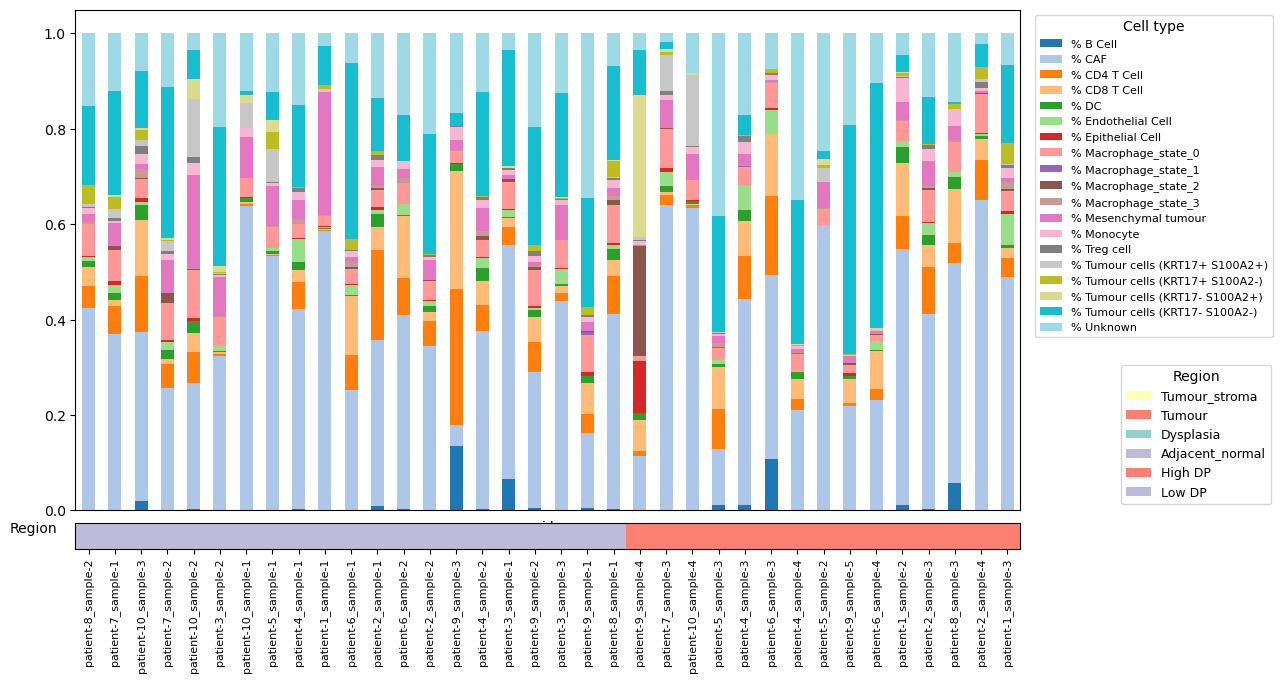

In [ ]:


#abundance plot
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch

data_bar = data_bar_comp.copy()

# enlever les samples Adjacent_normal
data_bar = data_bar[~data_bar["id"].isin(adjacent_ids)]

# sélectionner les colonnes CD8
#cd8_cols = data_bar.filter(regex=r"^% CD8")

#data_bar = data_bar[["id", "DP_group"] + cd8_cols.columns.tolist()]

#data_bar = data_bar[["id", "DP_group"]]
# --------- figure avec 2 axes ---------
fig = plt.figure(figsize=(18,7))
gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[20, 1],
    hspace=0.05
)

ax = fig.add_subplot(gs[0])
ax_loc = fig.add_subplot(gs[1])

# --------- stacked barplot ---------

# alignement selon region

data_bar = data_bar.sort_values("DP_group")

(
    data_bar
    .set_index("id")
    .drop(columns=["DP_group"])
    .plot(
        kind="bar",
        stacked=True,
        cmap="tab20",
        ax=ax
    )
)

# --------- localisation ---------
location_series = (
    data_bar_comp
    .set_index("id")
    .loc[data_bar["id"], "DP_group"]
)

unique_locations = location_series.dropna().unique()

'''
palette = sns.color_palette(
    "Set3",
    n_colors=len(unique_locations)
)

location_to_color = dict(
    zip(unique_locations, palette)
)
'''

if location_to_color == None:
    palette = sns.color_palette("Set3", n_colors=len(unique_locations))
    location_to_color = dict(zip(unique_locations, palette))

    
location_to_int = {
    loc: i
    for i, loc in enumerate(unique_locations)
}

location_ints = np.array([
    location_to_int.get(loc, -1)
    for loc in location_series
])

location_cmap = ListedColormap(
    [location_to_color[loc] for loc in unique_locations]
)

ax_loc.imshow(
    location_ints[np.newaxis, :],
    aspect="auto",
    cmap=location_cmap,
    interpolation="nearest"
)

ax_loc.set_yticks([])
ax_loc.set_ylabel(
    "Region",
    rotation=0,
    labelpad=30
)



# enlever labels du barplot
ax.set_xticklabels([])
ax.tick_params(axis="x", length=0)

# labels uniquement sur ax_loc
ax_loc.set_xticks(np.arange(len(location_ints)))
ax_loc.set_xticklabels(
    data_bar["id"],
    rotation=90,
    fontsize=8
)



# synchronisation (très important)
ax_loc.set_xlim(ax.get_xlim())

# -----------------------------
# LÉGENDE CELL TYPES (coin supérieur droit)
# -----------------------------
cell_legend = ax.legend(
    title="Cell type",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    frameon=True,
    fontsize=8
)

ax.add_artist(cell_legend)

# -----------------------------
# LÉGENDE REGIONS (coin inférieur droit)
# -----------------------------
region_handles = [
    Patch(facecolor=color, label=region)
    for region, color in location_to_color.items()
]

ax.legend(
    handles=region_handles,
    title="Region",
    loc="lower left",
    bbox_to_anchor=(1.1, 0.0),
    frameon=True,
    fontsize=9
)



# laisser de la place à droite
plt.subplots_adjust(right=0.65)

#plt.savefig(save_dir_plot / "tumor_status_abondance.png", bbox_inches="tight")
plt.show()